<a href="https://colab.research.google.com/github/CJmaz32/NCAA-March-Madness-Predictor/blob/main/March_Madness_2025.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install xlsxwriter

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 4.0 MB/s eta 0:00:00


In [2]:
!find . -name "patsy.py"


In [3]:
!pip uninstall -y patsy seaborn
!pip install patsy seaborn


Found existing installation: patsy 1.0.2
Uninstalling patsy-1.0.2:
  Successfully uninstalled patsy-1.0.2
Found existing installation: seaborn 0.13.2
Uninstalling seaborn-0.13.2:
  Successfully uninstalled seaborn-0.13.2
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 233.3/233.3 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 10.1 MB/s eta 0:00:00


In [4]:
# Load Libraries
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
import os
import xlsxwriter
from google.colab import drive

In [5]:
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
# Define Parameters
Project = "CJ"
# Available Projects: "Vladimir","Alex","Ben","CJ","Daniella","Julia","Kaisar","Kendall"

Projects = ["Alex","Ben","CJ","Daniella","Julia","Kaisar","Kendall","Vladimir"]

GradStudents      = ["Alex","Daniella","Kendall"]
UnderGradStudents = ["Ben","CJ","Julia","Kaisar"]

In [7]:
Files = []

if   Project == "CJ"       : Files = ['MRegularSeasonCompactResults.csv', '2025_tourney_seeds.csv','MTeams.csv', 'MNCAATourneySeeds.csv', 'MMasseyOrdinals.csv', 'MNCAATourneySeedRoundSlots.csv', 'MRegularSeasonDetailedResults.csv', "MNCAATourneySlots.csv", 'MSeasons.csv']
print(Files)

['MRegularSeasonCompactResults.csv', '2025_tourney_seeds.csv', 'MTeams.csv', 'MNCAATourneySeeds.csv', 'MMasseyOrdinals.csv', 'MNCAATourneySeedRoundSlots.csv', 'MRegularSeasonDetailedResults.csv', 'MNCAATourneySlots.csv', 'MSeasons.csv']


In [8]:
# Define Title of the Project
if  Project == "CJ"       : DataInfo = "NCAA - Bracket - Predictions"

print(DataInfo)

NCAA - Bracket - Predictions


In [9]:
# Define Project Source
if   Project == "CJ"       : DataSource = "https://www.kaggle.com/competitions/ncaam-march-mania-2021-spread/overview"

print(DataInfo)

NCAA - Bracket - Predictions


In [10]:
SHAREDPATH = "/content/drive/MyDrive/2025MarchMadness/"
INPUTPATH  = SHAREDPATH + "INPUT/"
OUTPUTPATH = SHAREDPATH + "OUTPUT/"


In [11]:
print(INPUTPATH)
print(OUTPUTPATH)

/content/drive/MyDrive/2025MarchMadness/INPUT/
/content/drive/MyDrive/2025MarchMadness/OUTPUT/


In [12]:
# List all avaialble files in the input folder
ListOfFile = os.listdir(INPUTPATH)
ListOfFile.sort()
for File in ListOfFile:
  print(File)

2025_tourney_seeds.csv
MMasseyOrdinals.csv
MNCAATourneySeedRoundSlots.csv
MNCAATourneySeeds.csv
MNCAATourneySlots.csv
MRegularSeasonCompactResults.csv
MRegularSeasonDetailedResults.csv
MSeasons.csv
MTeams.csv


In [13]:
# List Selected Files for the Project and confirm if selected files are avaialble:
for file in Files:
  if file in ListOfFile:
    print(file, "is available")
  else:
    print(file, "is NOT available")

# List of files that are avaialble but not listed in the Files:
print("\n")
print("List of available but not used files:")
for file in ListOfFile:
  if file not in Files:
    print(file, "is not listed")

MRegularSeasonCompactResults.csv is available
2025_tourney_seeds.csv is available
MTeams.csv is available
MNCAATourneySeeds.csv is available
MMasseyOrdinals.csv is available
MNCAATourneySeedRoundSlots.csv is available
MRegularSeasonDetailedResults.csv is available
MNCAATourneySlots.csv is available
MSeasons.csv is available


List of available but not used files:


In [14]:
# Read the first file:
for i in range(len(Files)):
  print("#"+str(i+1),"File",Files[i],"is read as inputfile"+str(1+i))

  if Project == "Kaisar":
    inputfile = pd.read_csv(INPUTPATH + "properties.csv", skiprows=3, dtype={"ZipCode": "str"}, on_bad_lines='skip', nrows=1000)
  elif Files[i][-4:]==".csv":
    inputfile = pd.read_csv(INPUTPATH + Files[i], encoding='unicode_escape')
  elif Files[i][-5:]==".xlsx":
    inputfile = pd.read_excel(INPUTPATH + Files[i])

  print("File Dimensions:",inputfile.shape[0],"rows &",inputfile.shape[1],"columns")
  print("First 5 records:")
  display(inputfile.head(5))

  if i==0: inputfile1 =inputfile.copy()
  if i==1: inputfile2 =inputfile.copy()
  if i==2: inputfile3 =inputfile.copy()
  if i==3: inputfile4 =inputfile.copy()
  if i==4: inputfile5 =inputfile.copy()
  if i==5: inputfile6 =inputfile.copy()
  if i==6: inputfile7 =inputfile.copy()
  if i==7: inputfile8 =inputfile.copy()
  if i==8: inputfile9 =inputfile.copy()
  if i==9: inputfile10 =inputfile.copy()

#1 File MRegularSeasonCompactResults.csv is read as inputfile1
File Dimensions: 192930 rows & 8 columns
First 5 records:


,Season,DayNum,WTeamID,WScore,LTeamID,LScore,WLoc,NumOT
0,1985,20,1228,81,1328,64,N,0
1,1985,25,1106,77,1354,70,H,0
2,1985,25,1112,63,1223,56,H,0
3,1985,25,1165,70,1432,54,H,0
4,1985,25,1192,86,1447,74,H,0


#2 File 2025_tourney_seeds.csv is read as inputfile2
File Dimensions: 68 rows & 3 columns
First 5 records:


,Season,Seed,TeamID
0,2025,W01,1181
1,2025,W02,1104
2,2025,W03,1458
3,2025,W04,1112
4,2025,W05,1332


#3 File MTeams.csv is read as inputfile3
File Dimensions: 380 rows & 4 columns
First 5 records:


...

,Season,DayNum,WTeamID,WScore,LTeamID,LScore,WLoc,NumOT,WFGM,WFGA,...,LFGA3,LFTM,LFTA,LOR,LDR,LAst,LTO,LStl,LBlk,LPF
0,2003,10,1104,68,1328,62,N,0,27,58,...,10,16,22,10,22,8,18,9,2,20
1,2003,10,1272,70,1393,63,N,0,26,62,...,24,9,20,20,25,7,12,8,6,16
2,2003,11,1266,73,1437,61,N,0,24,58,...,26,14,23,31,22,9,12,2,5,23
3,2003,11,1296,56,1457,50,N,0,18,38,...,22,8,15,17,20,9,19,4,3,23
4,2003,11,1400,77,1208,71,N,0,30,61,...,16,17,27,21,15,12,10,7,1,14


#8 File MNCAATourneySlots.csv is read as inputfile8
File Dimensions: 2586 rows & 4 columns
First 5 records:


,Season,Slot,StrongSeed,WeakSeed
0,1985,R1W1,W01,W16
1,1985,R1W2,W02,W15
2,1985,R1W3,W03,W14
3,1985,R1W4,W04,W13
4,1985,R1W5,W05,W12


#9 File MSeasons.csv is read as inputfile9
File Dimensions: 41 rows & 6 columns
First 5 records:


,Season,DayZero,RegionW,RegionX,RegionY,RegionZ
0,1985,10/29/1984,East,West,Midwest,Southeast
1,1986,10/28/1985,East,Midwest,Southeast,West
2,1987,10/27/1986,East,Southeast,Midwest,West
3,1988,11/02/1987,East,Midwest,Southeast,West
4,1989,10/31/1988,East,West,Midwest,Southeast


In [15]:
# Print Out Summary of the Data
print("Name: ",Project)
print("Data Details: ",DataInfo)
print("Files: ", end="")
for File in Files:
  print(File, end="")
  if File==Files[-1]: print("")
  else: print(", ", end="")

print("# Files in the Project:",len(Files))

if Project in GradStudents:
  print (Project,"is Graduate Student")
elif Project in UnderGradStudents:
  print (Project,"is Undergraduate Student")
else:
  print (Project,"is Name of the Project")

Name:  CJ
Data Details:  NCAA - Bracket - Predictions
Files: MRegularSeasonCompactResults.csv, 2025_tourney_seeds.csv, MTeams.csv, MNCAATourneySeeds.csv, MMasseyOrdinals.csv, MNCAATourneySeedRoundSlots.csv, MRegularSeasonDetailedResults.csv, MNCAATourneySlots.csv, MSeasons.csv
# Files in the Project: 9
CJ is Undergraduate Student


In [16]:
# Load the datasets
ncaatourney_seeds_df = inputfile4.copy()  # MNCAATourneySeeds.csv
massey_ordinals_df = inputfile5.copy()  # MMasseyOrdinals.csv

try:
    # Filter each dataset to only include rows where the season is 2025
    ncaatourney_seeds_2025 = ncaatourney_seeds_df[ncaatourney_seeds_df['Season'] == 2025]
    massey_ordinals_2025 = massey_ordinals_df[massey_ordinals_df['Season'] == 2025]

    # Merge the two datasets on TeamID
    merged_2025_df = pd.merge(
        ncaatourney_seeds_2025, massey_ordinals_2025, on=["TeamID","Season"], how="inner"
    )

    # Display and save the merged and filtered dataset
    merged_2025_df.to_csv("merged_ncaatourney_massey_2025.csv", index=False)
    print(merged_2025_df.head())
    print("Filtered dataset saved as 'merged_ncaatourney_massey_2025.csv'")
except Exception as e:
    print(f"Error during merging and filtering: {e}")





   Season Seed  TeamID  RankingDayNum SystemName  OrdinalRank
0    2025  W01    1181              9         AP            6
1    2025  W01    1181              9        BBT            8
2    2025  W01    1181              9        BWE           10
3    2025  W01    1181              9        DES            5
4    2025  W01    1181              9        DII            2
Filtered dataset saved as 'merged_ncaatourney_massey_2025.csv'


In [17]:
# Load the datasets
ncaatourney_seeds_df = inputfile4.copy()  # MNCAATourneySeeds.csv
massey_ordinals_df = inputfile5.copy()  # MMasseyOrdinals.csv
tourney_teams_df = inputfile2.copy()  # 2025_tourney_teams.csv

try:
    # Filter each dataset to only include rows where the season is 2025
    ncaatourney_seeds_2025 = ncaatourney_seeds_df[ncaatourney_seeds_df['Season'] == 2025]
    massey_ordinals_2054 = massey_ordinals_df[massey_ordinals_df['Season'] == 2025]

    # Ensure tourney_teams_df only contains unique TeamID values
    tourney_teams_unique = tourney_teams_df['TeamID'].drop_duplicates()

    # Merge the two datasets on TeamID
    merged_2025_df = pd.merge(
        ncaatourney_seeds_2025, massey_ordinals_2025, on=["TeamID", "Season"], how="inner"
    )

    # Filter the merged dataset to include only TeamIDs found in tourney_teams_df
    filtered_merged_2025_df = merged_2025_df[
        merged_2025_df['TeamID'].isin(tourney_teams_unique)
    ]

    # Display and save the merged and filtered dataset
    filtered_merged_2025_df.to_csv("filtered_merged_ncaatourney_massey_2025.csv", index=False)
    print(filtered_merged_2025_df.head())
    print("Filtered dataset saved as 'filtered_merged_ncaatourney_massey_2025.csv'")
except Exception as e:
    print(f"Error during merging and filtering: {e}")


   Season Seed  TeamID  RankingDayNum SystemName  OrdinalRank
0    2025  W01    1181              9         AP            6
1    2025  W01    1181              9        BBT            8
2    2025  W01    1181              9        BWE           10
3    2025  W01    1181              9        DES            5
4    2025  W01    1181              9        DII            2
Filtered dataset saved as 'filtered_merged_ncaatourney_massey_2025.csv'


In [18]:
# Load the final dataset and MTeams.csv
final_filtered_dataset = pd.read_csv("filtered_merged_ncaatourney_massey_2025.csv")  # Previously saved dataset
teams_df = inputfile3.copy()  # MTeams.csv

try:
    # Merge the final dataset with MTeams.csv to include team names
    final_with_team_names_df = pd.merge(
        final_filtered_dataset, teams_df, on="TeamID", how="inner"
    )

    # Drop the unnecessary columns
    final_with_team_names_df = final_with_team_names_df.drop(columns=["FirstD1Season", "LastD1Season"])

    # Save and display the updated dataset
    final_with_team_names_df.to_csv("Team-Seed-Ranking-Data.csv", index=False)
    print(final_with_team_names_df.head())
    print("Final dataset with team names saved as 'Team-Seed-Ranking-Data.csv'")
except Exception as e:
    print(f"Error during merging and filtering: {e}")

final_with_team_names_df

   Season Seed  TeamID  RankingDayNum SystemName  OrdinalRank TeamName
0    2025  W01    1181              9         AP            6     Duke
1    2025  W01    1181              9        BBT            8     Duke
2    2025  W01    1181              9        BWE           10     Duke
3    2025  W01    1181              9        DES            5     Duke
4    2025  W01    1181              9        DII            2     Duke
Final dataset with team names saved as 'Team-Seed-Ranking-Data.csv'


,Season,Seed,TeamID,RankingDayNum,SystemName,OrdinalRank,TeamName
0,2025,W01,1181,9,AP,6,Duke
1,2025,W01,1181,9,BBT,8,Duke
2,2025,W01,1181,9,BWE,10,Duke
3,2025,W01,1181,9,DES,5,Duke
4,2025,W01,1181,9,DII,2,Duke
...,...,...,...,...,...,...,...
53597,2025,Z16,1313,128,TRP,170,Norfolk St
53598,2025,Z16,1313,128,WAB,120,Norfolk St
53599,2025,Z16,1313,128,WIL,193,Norfolk St
53600,2025,Z16,1313,128,WLK,153,Norfolk St


In [19]:
# Import necessary libraries
import pandas as pd

# Load the dataset (ensure the file is uploaded to Colab or available at the specified path)
file_path = 'Team-Seed-Ranking-Data.csv'  # Update with the actual file path in Colab
team_seed_ranking_data = pd.read_csv(file_path)

# Filter the data to only include rows where RankingDayNum equals 128
filtered_data = team_seed_ranking_data[team_seed_ranking_data['RankingDayNum'] == 128]

# Save the filtered dataset to a CSV file
filtered_file_path = 'Filtered-Team-Seed-Ranking-Day128.csv'
filtered_data.to_csv(filtered_file_path, index=False)

# Display the first few rows of the filtered data
print("Filtered data:")
print(filtered_data.head())



Filtered data:
     Season Seed  TeamID  RankingDayNum SystemName  OrdinalRank TeamName
766    2025  W01    1181            128        7OT            2     Duke
767    2025  W01    1181            128         AP            1     Duke
768    2025  W01    1181            128        BAR            1     Duke
769    2025  W01    1181            128        BBT            2     Duke
770    2025  W01    1181            128        BIH            3     Duke


In [20]:
# Import necessary libraries
import pandas as pd

# Load the dataset (ensure the file is uploaded to Colab or available at the specified path)
file_path = 'Team-Seed-Ranking-Data.csv'  # Update with the actual file path in Colab
team_seed_ranking_data = pd.read_csv(file_path)

# Filter the data to only include rows where RankingDayNum equals 128
filtered_data = team_seed_ranking_data[team_seed_ranking_data['RankingDayNum'] == 128]

# Save the filtered dataset to a CSV file
filtered_file_path = 'Filtered-Team-Seed-Ranking-Day128.csv'
filtered_data.to_csv(filtered_file_path, index=False)

# Display the first few rows of the filtered data
print("Filtered data:")
print(filtered_data.head())

# Pivot the dataset to make each SystemName a column with OrdinalRank as values
pivoted_data = filtered_data.pivot(
    index='TeamName',  # Rows will be team names
    columns='SystemName',  # Columns will be ranking systems
    values='OrdinalRank'  # Values will be ordinal ranks
).reset_index()

# Save the pivoted dataset to a new CSV file
pivoted_file_path = 'Pivoted-Team-Seed-Ranking-Day128.csv'
pivoted_data.to_csv(pivoted_file_path, index=False)

# Display the first few rows of the pivoted data
print("\nPivoted data:")
print(pivoted_data.head())


Filtered data:
     Season Seed  TeamID  RankingDayNum SystemName  OrdinalRank TeamName
766    2025  W01    1181            128        7OT            2     Duke
767    2025  W01    1181            128         AP            1     Duke
768    2025  W01    1181            128        BAR            1     Duke
769    2025  W01    1181            128        BBT            2     Duke
770    2025  W01    1181            128        BIH            3     Duke

Pivoted data:
SystemName       TeamName    7OT   AP    BAR    BBT    BIH    BMN    BNZ  \
0                   Akron   51.0  NaN  118.0   83.0   71.0   72.0  109.0   
1                 Alabama    3.0  5.0    6.0    6.0    6.0    2.0    5.0   
2              Alabama St  314.0  NaN  274.0  291.0  274.0  235.0  280.0   
3           American Univ  184.0  NaN  262.0  204.0  198.0  178.0  259.0   
4                 Arizona   19.0  NaN   12.0   32.0   27.0   28.0   12.0   

SystemName    BWE    COL  ...    SPR    SRS    STY    TRK    TRP   USA    W

In [21]:
# Import necessary libraries
import pandas as pd

# Load the dataset (ensure the file is uploaded to Colab or available at the specified path)
file_path = 'Team-Seed-Ranking-Data.csv'  # Update with the actual file path in Colab
team_seed_ranking_data = pd.read_csv(file_path)

# Filter the data to only include rows where RankingDayNum equals 128
filtered_data = team_seed_ranking_data[team_seed_ranking_data['RankingDayNum'] == 128]

# Save the filtered dataset to a CSV file
filtered_file_path = 'Filtered-Team-Seed-Ranking-Day128.csv'
filtered_data.to_csv(filtered_file_path, index=False)

# Pivot the dataset to make each SystemName a column with OrdinalRank as values
pivoted_data = filtered_data.pivot(
    index='TeamName',  # Rows will be team names
    columns='SystemName',  # Columns will be ranking systems
    values='OrdinalRank'  # Values will be ordinal ranks
).reset_index()

# Filter the pivoted dataset to include only specified ranking systems
selected_systems = ["POM", "KPI", "SRS", "USA","SPR", "RPI","WIL"]
filtered_pivoted_data = pivoted_data[["TeamName"] + selected_systems]

# Merge the pivoted table back with the filtered original data on TeamName
merged_data = pd.merge(filtered_data, filtered_pivoted_data, on="TeamName", how="inner")

# Save the merged dataset to a new CSV file
merged_file_path = 'Merged-Team-Seed-Ranking-Day128.csv'
merged_data.to_csv(merged_file_path, index=False)

# Display the first few rows of the merged data
print("Merged Data:")
print(merged_data.head())


Merged Data:
   Season Seed  TeamID  RankingDayNum SystemName  OrdinalRank TeamName  POM  \
0    2025  W01    1181            128        7OT            2     Duke  1.0   
1    2025  W01    1181            128         AP            1     Duke  1.0   
2    2025  W01    1181            128        BAR            1     Duke  1.0   
3    2025  W01    1181            128        BBT            2     Duke  1.0   
4    2025  W01    1181            128        BIH            3     Duke  1.0   

   KPI  SRS  USA  SPR  RPI  WIL  
0  7.0  1.0  1.0  5.0  5.0  5.0  
1  7.0  1.0  1.0  5.0  5.0  5.0  
2  7.0  1.0  1.0  5.0  5.0  5.0  
3  7.0  1.0  1.0  5.0  5.0  5.0  
4  7.0  1.0  1.0  5.0  5.0  5.0  


In [22]:
# Import necessary libraries
import pandas as pd

# Load the merged dataset
merged_file_path = 'Merged-Team-Seed-Ranking-Day128.csv'
merged_data = pd.read_csv(merged_file_path)

# Select relevant columns for visualization (TeamName and ranking systems)
ranking_columns = ["POM", "KPI", "SRS", "USA","SPR", "RPI", "WIL"]
visualization_data = merged_data[["TeamName"] + ranking_columns]

# Calculate the average rank across the selected ranking systems for each team
visualization_data['AverageRank'] = visualization_data[ranking_columns].mean(axis=1)

# Display the updated dataset with the new AverageRank column
print("Updated Data with Average Rank:")
print(visualization_data.head(10))



Updated Data with Average Rank:
  TeamName  POM  KPI  SRS  USA  SPR  RPI  WIL  AverageRank
0     Duke  1.0  7.0  1.0  1.0  5.0  5.0  5.0     3.571429
1     Duke  1.0  7.0  1.0  1.0  5.0  5.0  5.0     3.571429
2     Duke  1.0  7.0  1.0  1.0  5.0  5.0  5.0     3.571429
3     Duke  1.0  7.0  1.0  1.0  5.0  5.0  5.0     3.571429
4     Duke  1.0  7.0  1.0  1.0  5.0  5.0  5.0     3.571429
5     Duke  1.0  7.0  1.0  1.0  5.0  5.0  5.0     3.571429
6     Duke  1.0  7.0  1.0  1.0  5.0  5.0  5.0     3.571429
7     Duke  1.0  7.0  1.0  1.0  5.0  5.0  5.0     3.571429
8     Duke  1.0  7.0  1.0  1.0  5.0  5.0  5.0     3.571429
9     Duke  1.0  7.0  1.0  1.0  5.0  5.0  5.0     3.571429


/tmp/ipykernel_20311/1612178574.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  visualization_data['AverageRank'] = visualization_data[ranking_columns].mean(axis=1)


In [23]:
# Import necessary libraries
import pandas as pd

# Load the merged dataset
merged_file_path = 'Merged-Team-Seed-Ranking-Day128.csv'
merged_data = pd.read_csv(merged_file_path)

# Select relevant columns for visualization (TeamName and ranking systems)
ranking_columns = ["POM", "KPI", "SRS", "USA","SPR", "RPI", "WIL"]

# Retain only the required columns: TeamName, ranking systems
visualization_data = merged_data[["TeamName"] + ranking_columns]

# Remove duplicates by grouping by TeamName and taking the mean
visualization_data = visualization_data.groupby("TeamName", as_index=False).mean()

# Calculate the average rank across the selected ranking systems for each team
visualization_data['AverageRank'] = visualization_data[ranking_columns].mean(axis=1)

# Keep only the TeamName, ranking systems, and AverageRank columns
columns_to_keep = ["TeamName"] + ranking_columns + ["AverageRank"]
final_data = visualization_data[columns_to_keep]

# Display the final dataset
print("Simplified Data:")
print(final_data.head())


Simplified Data:
        TeamName    POM    KPI    SRS   USA    SPR    RPI    WIL  AverageRank
0          Akron  100.0   72.0  115.0   NaN   98.0   44.0   88.0    86.166667
1        Alabama    6.0    2.0    5.0   8.0    3.0    2.0    3.0     4.142857
2     Alabama St  280.0  275.0  285.0   NaN  264.0  263.0  284.0   275.166667
3  American Univ  248.0  217.0  261.0   NaN  263.0  157.0  199.0   224.166667
4        Arizona   16.0   28.0   11.0  24.0   29.0   37.0   33.0    25.428571


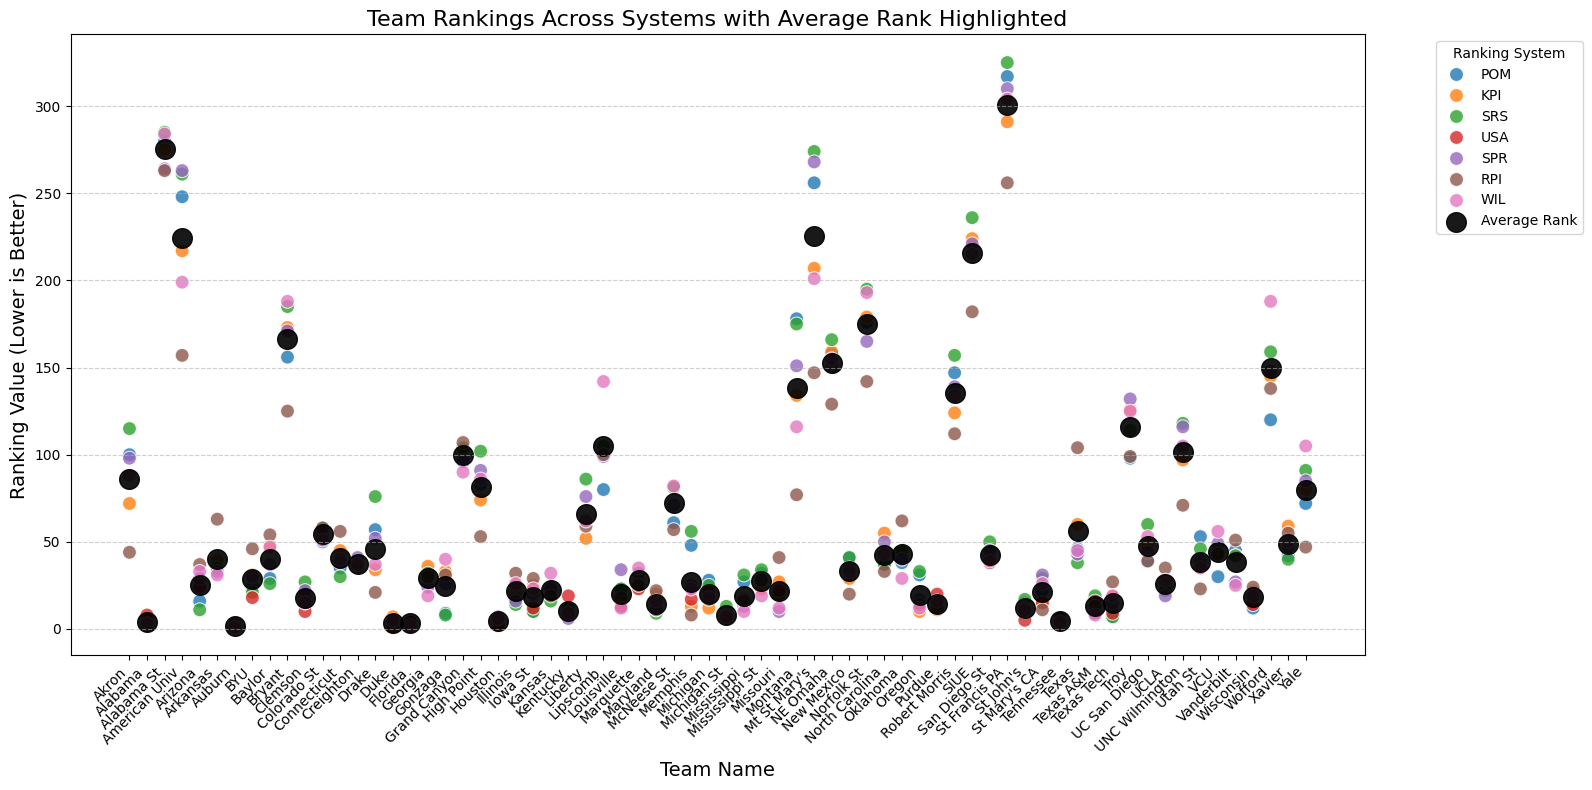

In [24]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the merged dataset
merged_file_path = 'Merged-Team-Seed-Ranking-Day128.csv'
merged_data = pd.read_csv(merged_file_path)

# Select relevant columns for visualization (TeamName and ranking systems)
ranking_columns = ["POM", "KPI", "SRS", "USA","SPR", "RPI", "WIL"]

# Retain only the required columns: TeamName, ranking systems
visualization_data = merged_data[["TeamName"] + ranking_columns]

# Remove duplicates by grouping by TeamName and taking the mean
visualization_data = visualization_data.groupby("TeamName", as_index=False).mean()

# Calculate the average rank across the selected ranking systems for each team
visualization_data['AverageRank'] = visualization_data[ranking_columns].mean(axis=1)

# Melt the data for visualization
melted_data = visualization_data.melt(
    id_vars=["TeamName", "AverageRank"],
    value_vars=ranking_columns,
    var_name="RankingSystem",
    value_name="RankingValue"
)

# Create the dot chart
plt.figure(figsize=(16, 8))
sns.scatterplot(
    data=melted_data,
    x="TeamName",
    y="RankingValue",
    hue="RankingSystem",
    s=100,
    alpha=0.8,
    palette="tab10"
)

# Emphasize average rank with larger black dots
plt.scatter(
    x=range(len(visualization_data["TeamName"])),
    y=visualization_data["AverageRank"],
    color="black",
    label="Average Rank",
    s=200,
    alpha=0.9
)

# Customize the chart
plt.title("Team Rankings Across Systems with Average Rank Highlighted", fontsize=16)
plt.xlabel("Team Name", fontsize=14)
plt.ylabel("Ranking Value (Lower is Better)", fontsize=14)
plt.xticks(
    ticks=range(len(visualization_data["TeamName"])),
    labels=visualization_data["TeamName"],
    rotation=45,
    ha="right"
)
plt.legend(title="Ranking System", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()

# Show the plot
plt.show()




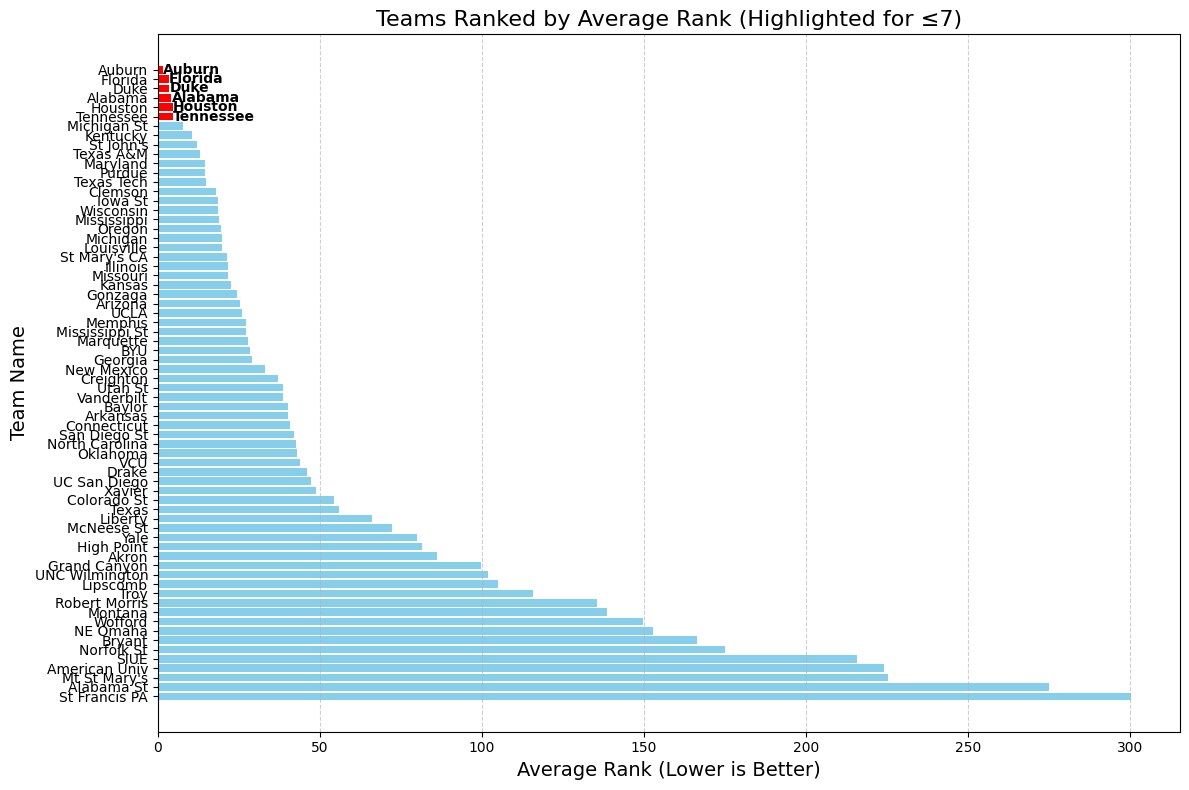

In [25]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt

# Load the merged dataset
merged_file_path = 'Merged-Team-Seed-Ranking-Day128.csv'
merged_data = pd.read_csv(merged_file_path)

# Select relevant columns for visualization (TeamName and ranking systems)
ranking_columns = ["POM", "KPI", "SRS", "USA","SPR", "RPI", "WIL"]

# Retain only the required columns: TeamName, ranking systems
visualization_data = merged_data[["TeamName"] + ranking_columns]

# Remove duplicates by grouping by TeamName and taking the mean
visualization_data = visualization_data.groupby("TeamName", as_index=False).mean()

# Calculate the average rank across the selected ranking systems for each team
visualization_data['AverageRank'] = visualization_data[ranking_columns].mean(axis=1)

# Sort the teams by their average rank in ascending order
sorted_data = visualization_data.sort_values("AverageRank")

# Highlight teams with an average rank of 7 or below
highlight_mask = sorted_data["AverageRank"] <= 7

# Create a bar chart for the average rank
plt.figure(figsize=(12, 8))

# Plot highlighted bars for teams with average rank <= 7
plt.barh(
    sorted_data["TeamName"],
    sorted_data["AverageRank"],
    color=['red' if highlight else 'skyblue' for highlight in highlight_mask]
)

# Customize the chart
plt.title("Teams Ranked by Average Rank (Highlighted for ≤7)", fontsize=16)
plt.xlabel("Average Rank (Lower is Better)", fontsize=14)
plt.ylabel("Team Name", fontsize=14)
plt.gca().invert_yaxis()  # Invert y-axis to show the best team at the top

# Annotate team names with bold text for highlighted teams
for i, (team, avg_rank, highlight) in enumerate(zip(sorted_data["TeamName"], sorted_data["AverageRank"], highlight_mask)):
    if highlight:
        plt.text(avg_rank + 0.1, i, f'{team}', va='center', ha='left', fontsize=10, fontweight='bold', color='black')

plt.grid(axis="x", linestyle="--", alpha=0.6)
plt.tight_layout()

# Show the plot
plt.show()




In [26]:
# Import necessary libraries
import pandas as pd

# Load the merged dataset
merged_file_path = 'Merged-Team-Seed-Ranking-Day128.csv'
merged_data = pd.read_csv(merged_file_path)

# Select relevant columns for visualization
ranking_columns = ["POM", "KPI", "SRS", "USA","SPR", "RPI", "WIL"]
additional_columns = ["Season", "Seed", "TeamID", "TeamName"]  # Add these columns back

# Retain the required columns
visualization_data = merged_data[additional_columns + ranking_columns]

# Remove duplicates by grouping by TeamName, Season, Seed, and TeamID
visualization_data = visualization_data.groupby(["Season", "Seed", "TeamID", "TeamName"], as_index=False).mean()

# Calculate the average rank across the selected ranking systems for each team
visualization_data['AverageRank'] = visualization_data[ranking_columns].mean(axis=1)

# Keep only the TeamName, Season, Seed, TeamID, ranking systems, and AverageRank columns
columns_to_keep = ["Season", "Seed", "TeamID", "TeamName"] + ranking_columns + ["AverageRank"]
final_data = visualization_data[columns_to_keep]

# Save the final dataset to a CSV file
export_file_path = 'Final_Team_Rankings_with_Seed_Season_TeamID.csv'
final_data.to_csv(export_file_path, index=False)

print(f"Data exported to: {export_file_path}")


Data exported to: Final_Team_Rankings_with_Seed_Season_TeamID.csv


In [27]:
# Read the exported CSV file
import pandas as pd
df = pd.read_csv('Final_Team_Rankings_with_Seed_Season_TeamID.csv')
print(df.head())
from google.colab import files
files.download('Final_Team_Rankings_with_Seed_Season_TeamID.csv')



   Season Seed  TeamID   TeamName   POM   KPI   SRS   USA   SPR   RPI   WIL  \
0    2025  W01    1181       Duke   1.0   7.0   1.0   1.0   5.0   5.0   5.0   
1    2025  W02    1104    Alabama   6.0   2.0   5.0   8.0   3.0   2.0   3.0   
2    2025  W03    1458  Wisconsin  12.0  22.0  18.0  14.0  21.0  24.0  19.0   
3    2025  W04    1112    Arizona  16.0  28.0  11.0  24.0  29.0  37.0  33.0   
4    2025  W05    1332     Oregon  31.0  10.0  33.0   NaN  17.0  14.0  12.0   

   AverageRank  
0     3.571429  
1     4.142857  
2    18.571429  
3    25.428571  
4    19.500000  


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [28]:
# Load the datasets
MRegularSeasonCompactResults_df = inputfile1.copy()  # MRegularSeasonCompactResults
MRegularSeasonDetailedResults_df = inputfile7.copy()  # MRegularSeasonDetailedReults

print(MRegularSeasonCompactResults_df.head())
print(MRegularSeasonDetailedResults_df.head())




   Season  DayNum  WTeamID  WScore  LTeamID  LScore WLoc  NumOT
0    1985      20     1228      81     1328      64    N      0
1    1985      25     1106      77     1354      70    H      0
2    1985      25     1112      63     1223      56    H      0
3    1985      25     1165      70     1432      54    H      0
4    1985      25     1192      86     1447      74    H      0
   Season  DayNum  WTeamID  WScore  LTeamID  LScore WLoc  NumOT  WFGM  WFGA  \
0    2003      10     1104      68     1328      62    N      0    27    58   
1    2003      10     1272      70     1393      63    N      0    26    62   
2    2003      11     1266      73     1437      61    N      0    24    58   
3    2003      11     1296      56     1457      50    N      0    18    38   
4    2003      11     1400      77     1208      71    N      0    30    61   

   ...  LFGA3  LFTM  LFTA  LOR  LDR  LAst  LTO  LStl  LBlk  LPF  
0  ...     10    16    22   10   22     8   18     9     2   20  
1  ...   

In [29]:
# Filter the detailed results dataset for the 2025 season
MRegularSeasonDetailedResults_2025 = MRegularSeasonDetailedResults_df[MRegularSeasonDetailedResults_df['Season'] == 2025]

# Display the first few rows of the filtered dataset
print("Detailed Results - 2025 Season:")
print(MRegularSeasonDetailedResults_2025.head())

# Optionally, save the filtered dataset to a CSV file
MRegularSeasonDetailedResults_2025.to_csv("MRegularSeasonDetailedResults_2025.csv", index=False)
print("Filtered data saved to 'MRegularSeasonDetailedResults_2025.csv'")


Detailed Results - 2025 Season:
        Season  DayNum  WTeamID  WScore  LTeamID  LScore WLoc  NumOT  WFGM  \
113241    2025       0     1104     110     1421      54    H      0    38   
113242    2025       0     1112      93     1145      64    H      0    33   
113243    2025       0     1117      80     1103      75    H      1    34   
113244    2025       0     1119      67     1107      59    H      0    22   
113245    2025       0     1130      69     1154      60    H      0    21   

        WFGA  ...  LFGA3  LFTM  LFTA  LOR  LDR  LAst  LTO  LStl  LBlk  LPF  
113241    60  ...     26     8    14   13   12     8    8     6     2   22  
113242    68  ...     26    10    13    4   18    12   19     7     1   20  
113243    73  ...     34     9    13   16   30    19   14     9     3   11  
113244    50  ...     24    11    16    5   25    11    9     8     2   24  
113245    54  ...     24    17    25    8   21    11   14     8     5   22  

[5 rows x 34 columns]
Filtered data 

In [30]:
# Filter the dataset for the 2025 season
MRegularSeasonDetailedResults_2025 = MRegularSeasonDetailedResults_df[MRegularSeasonDetailedResults_df['Season'] == 2025]

# Select columns related to winning teams
winning_columns = [col for col in MRegularSeasonDetailedResults_2025.columns if col.startswith('W') or col == 'Season']
winning_data = MRegularSeasonDetailedResults_2025[winning_columns]

# Exclude non-numeric columns for averaging
numeric_winning_data = winning_data.select_dtypes(include=['number'])

# Group by WTeamID to calculate averages
winning_averages = numeric_winning_data.groupby(MRegularSeasonDetailedResults_2025['WTeamID']).mean()

# Display the resulting DataFrame
print("Averages for Each Team When They Win (2025 Season):")
print(winning_averages.head())

# Optionally save the results to a CSV file
winning_averages.to_csv("Winning_Team_Averages_2025.csv")
print("Winning team averages for 2025 saved to 'Winning_Team_Averages_2025.csv'")


Averages for Each Team When They Win (2025 Season):
         Season  WTeamID     WScore       WFGM       WFGA      WFGM3  \
WTeamID                                                                
1101     2025.0   1101.0  76.230769  26.384615  55.153846   4.692308   
1102     2025.0   1102.0  74.000000  26.500000  51.750000  12.000000   
1103     2025.0   1103.0  87.038462  31.115385  63.576923  11.153846   
1104     2025.0   1104.0  93.960000  32.080000  64.720000  10.840000   
1105     2025.0   1105.0  82.428571  26.857143  58.428571   7.285714   

             WFGA3       WFTM       WFTA        WOR        WDR       WAst  \
WTeamID                                                                     
1101     13.692308  18.769231  24.000000   8.615385  22.076923  12.923077   
1102     27.500000   9.000000  13.750000   5.250000  22.750000  20.250000   
1103     30.038462  13.653846  18.076923  10.269231  25.269231  18.692308   
1104     30.200000  18.960000  26.480000  11.520000  28.88

In [31]:
# Filter the dataset for the 2025 season
MRegularSeasonDetailedResults_2025 = MRegularSeasonDetailedResults_df[MRegularSeasonDetailedResults_df['Season'] == 2025]

# Select columns related to winning teams
losing_columns = [col for col in MRegularSeasonDetailedResults_2025.columns if col.startswith('L') or col == 'Season']
losing_data = MRegularSeasonDetailedResults_2025[losing_columns]

# Exclude non-numeric columns for averaging
numeric_losing_data = losing_data.select_dtypes(include=['number'])

# Group by WTeamID to calculate averages
losing_averages = numeric_losing_data.groupby(MRegularSeasonDetailedResults_2025['LTeamID']).mean()

# Display the resulting DataFrame
print("Averages for Each Team When They Lose (2023 Season):")
print(losing_averages.head())

# Optionally save the results to a CSV file
losing_averages.to_csv("Losing_Team_Averages_2025.csv")
print("Losing team averages for 2025 saved to 'Losing_Team_Averages_2025.csv'")


Averages for Each Team When They Lose (2023 Season):
         Season  LTeamID     LScore       LFGM       LFGA     LFGM3  \
LTeamID                                                               
1101     2025.0   1101.0  60.500000  22.437500  57.125000  3.625000   
1102     2025.0   1102.0  60.214286  20.500000  50.321429  7.535714   
1103     2025.0   1103.0  70.666667  26.333333  66.500000  8.500000   
1104     2025.0   1104.0  82.250000  28.000000  63.500000  9.125000   
1105     2025.0   1105.0  65.136364  21.954545  60.227273  7.772727   

             LFGA3       LFTM       LFTA        LOR        LDR       LAst  \
LTeamID                                                                     
1101     14.625000  12.000000  18.375000   8.687500  17.562500  12.125000   
1102     24.035714  11.678571  18.464286   6.035714  20.678571  12.392857   
1103     25.000000   9.500000  13.333333   8.666667  23.166667  13.333333   
1104     28.500000  17.125000  23.875000   9.250000  26.750000  

In [32]:
# 1. Opponent averages when the team wins
# Select losing team stats (`L` columns) and the winning team ID (`WTeamID`)
losing_columns = [col for col in MRegularSeasonDetailedResults_df.columns if col.startswith('L')]
opponents_when_team_wins = MRegularSeasonDetailedResults_df[['WTeamID'] + losing_columns]

# Keep only numeric columns for averaging
numeric_opponents_when_team_wins = opponents_when_team_wins.select_dtypes(include=['number'])

# Group by WTeamID to calculate averages
opponent_averages_when_winning = numeric_opponents_when_team_wins.groupby('WTeamID').mean()

# 2. Opponent averages when the team loses
# Select winning team stats (`W` columns) and the losing team ID (`LTeamID`)
winning_columns = [col for col in MRegularSeasonDetailedResults_df.columns if col.startswith('W')]
opponents_when_team_loses = MRegularSeasonDetailedResults_df[['LTeamID'] + winning_columns]

# Keep only numeric columns for averaging
numeric_opponents_when_team_loses = opponents_when_team_loses.select_dtypes(include=['number'])

# Group by LTeamID to calculate averages
opponent_averages_when_losing = numeric_opponents_when_team_loses.groupby('LTeamID').mean()

# Display the resulting DataFrames
print("Opponent Averages When Teams Win:")
print(opponent_averages_when_winning.head())

print("\nOpponent Averages When Teams Lose:")
print(opponent_averages_when_losing.head())

# Optionally save the results to separate CSV files
opponent_averages_when_winning.to_csv("Opponent_Averages_When_Teams_Win.csv")
opponent_averages_when_losing.to_csv("Opponent_Averages_When_Teams_Lose.csv")

print("Opponent averages saved to 'Opponent_Averages_When_Teams_Win.csv' and 'Opponent_Averages_When_Teams_Lose.csv'")


Opponent Averages When Teams Win:
             LTeamID     LScore       LFGM       LFGA     LFGM3      LFGA3  \
WTeamID                                                                      
1101     1306.664474  65.427632  22.256579  51.927632  5.282895  17.447368   
1102     1308.465035  57.349650  20.475524  50.597902  6.062937  19.804196   
1103     1252.323404  63.459574  22.646809  56.191489  5.725532  18.725532   
1104     1277.110609  64.334086  23.099323  59.595937  6.097065  20.747178   
1105     1244.939698  63.050251  22.216080  58.130653  4.974874  18.311558   

              LFTM       LFTA        LOR        LDR       LAst        LTO  \
WTeamID                                                                     
1101     15.631579  22.480263   8.914474  22.907895  10.394737  17.098684   
1102     10.335664  15.192308   9.325175  20.416084  10.534965  14.101399   
1103     12.440426  18.270213  10.663830  21.453191  10.461702  13.874468   
1104     12.038375  17.821670  11.

In [33]:
# Reset the index for both DataFrames to prepare for merging
opponent_averages_when_winning = opponent_averages_when_winning.reset_index()
opponent_averages_when_losing = opponent_averages_when_losing.reset_index()

# Rename columns to distinguish between winning and losing scenarios
opponent_averages_when_winning = opponent_averages_when_winning.rename(columns={"WTeamID": "TeamID"})
opponent_averages_when_losing = opponent_averages_when_losing.rename(columns={"LTeamID": "TeamID"})

# Combine the two datasets into one
combined_opponent_averages = pd.concat([opponent_averages_when_winning, opponent_averages_when_losing], ignore_index=True)

# Group by TeamID and calculate overall defensive averages
defensive_averages = combined_opponent_averages.groupby('TeamID').mean()

# Display the resulting DataFrame
print("Overall Defensive Averages for Each Team:")
print(defensive_averages.head())

# Save the defensive averages to a CSV file
defensive_averages.to_csv("Overall_Defensive_Averages.csv")
print("Defensive averages saved to 'Overall_Defensive_Averages.csv'")


Overall Defensive Averages for Each Team:
            LTeamID     LScore       LFGM       LFGA     LFGM3      LFGA3  \
TeamID                                                                      
1101    1306.664474  65.427632  22.256579  51.927632  5.282895  17.447368   
1102    1308.465035  57.349650  20.475524  50.597902  6.062937  19.804196   
1103    1252.323404  63.459574  22.646809  56.191489  5.725532  18.725532   
1104    1277.110609  64.334086  23.099323  59.595937  6.097065  20.747178   
1105    1244.939698  63.050251  22.216080  58.130653  4.974874  18.311558   

             LFTM       LFTA        LOR        LDR  ...      WFGA3       WFTM  \
TeamID                                              ...                         
1101    15.631579  22.480263   8.914474  22.907895  ...  17.488235  17.482353   
1102    10.335664  15.192308   9.325175  20.416084  ...  20.666667  14.942708   
1103    12.440426  18.270213  10.663830  21.453191  ...  17.938272  15.872428   
1104    12.03

In [34]:
import pandas as pd

# Load the previously saved Overall_Defensive_Averages.csv
file_path = "Overall_Defensive_Averages.csv"  # Adjust the path if needed
defensive_averages = pd.read_csv(file_path)

# Drop the LTeamID and WTeamID columns if they exist
columns_to_drop = ["LTeamID", "WTeamID"]
defensive_averages = defensive_averages.drop(columns=[col for col in columns_to_drop if col in defensive_averages.columns])

# Save the cleaned defensive averages to a new CSV file
cleaned_file_path = "Cleaned_Overall_Defensive_Averages.csv"
defensive_averages.to_csv(cleaned_file_path, index=False)

print(f"LTeamID and WTeamID removed (if they existed), and the cleaned data is saved to '{cleaned_file_path}'.")


LTeamID and WTeamID removed (if they existed), and the cleaned data is saved to 'Cleaned_Overall_Defensive_Averages.csv'.


In [35]:
from google.colab import files
files.download("Cleaned_Overall_Defensive_Averages.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [36]:
import pandas as pd

# Load the cleaned defensive averages CSV
file_path = "Cleaned_Overall_Defensive_Averages.csv"  # Update this path if necessary
data = pd.read_csv(file_path)

# Add new columns for calculated statistics

# Points Per Possession (PPP)
data['PPP'] = data['WScore'] / (data['WFGA'] - data['WOR'] + data['WTO'] + 0.475 * data['WFTA'])

# Effective Field Goal Percentage (eFG%)
data['eFG%'] = (data['WFGM'] + 0.5 * data['WFGM3']) / data['WFGA']

# Offensive Rebound Percentage (ORB%)
data['ORB%'] = data['WOR'] / (data['WOR'] + data['LDR'])

# Assist-to-Turnover Ratio (AST/TO)
data['AST/TO'] = data['WAst'] / data['WTO']

# Free Throw Rate (FTR)
data['FTR'] = data['WFTA'] / data['WFGA']

# Save the updated dataset to a new CSV file
output_file_path = "Cleaned_Overall_Offensive_Stats.csv"
data.to_csv(output_file_path, index=False)

print(f"Offensive statistics added and saved to '{output_file_path}'.")
print("Example Data with Calculated Offensive Statistic:")
print(data)


Offensive statistics added and saved to 'Cleaned_Overall_Offensive_Stats.csv'.
Example Data with Calculated Offensive Statistic:
     TeamID     LScore       LFGM       LFGA     LFGM3      LFGA3       LFTM  \
0      1101  65.427632  22.256579  51.927632  5.282895  17.447368  15.631579   
1      1102  57.349650  20.475524  50.597902  6.062937  19.804196  10.335664   
2      1103  63.459574  22.646809  56.191489  5.725532  18.725532  12.440426   
3      1104  64.334086  23.099323  59.595937  6.097065  20.747178  12.038375   
4      1105  63.050251  22.216080  58.130653  4.974874  18.311558  13.643216   
..      ...        ...        ...        ...       ...        ...        ...   
366    1476  64.827586  23.586207  58.551724  6.862069  21.827586  10.793103   
367    1477  68.777778  24.666667  58.333333  5.370370  18.740741  14.074074   
368    1478  65.157895  23.263158  60.157895  7.263158  25.631579  11.368421   
369    1479  65.750000  22.000000  51.166667  7.166667  21.833333  14.5

In [37]:
import pandas as pd

# Load the dataset
file_path = "Cleaned_Overall_Defensive_Averages.csv"  # Update the path if needed
data = pd.read_csv(file_path)

# Check for required columns and fill missing values if necessary
required_columns = ['LScore', 'LFGA', 'LOR', 'LTO', 'LFTA', 'LFGM', 'LFGM3', 'WDR', 'TeamID']
for col in required_columns:
    if col not in data.columns:
        print(f"Column {col} is missing from the dataset.")
    else:
        data[col] = pd.to_numeric(data[col], errors='coerce').fillna(0)  # Convert to numeric and fill missing values

# Add defensive metrics to the dataset

# Opponent Points Per Possession (Opp PPP)
data['Opp PPP'] = data['LScore'] / (data['LFGA'] - data['LOR'] + data['LTO'] + 0.475 * data['LFTA'])

# Opponent Effective Field Goal Percentage (Opp eFG%)
data['Opp eFG%'] = (data['LFGM'] + 0.5 * data['LFGM3']) / data['LFGA']

# Defensive Rebound Percentage (DRB%)
data['DRB%'] = data['WDR'] / (data['WDR'] + data['LOR'])

# Opponent Turnover Rate (Opp TO%)
data['Opp TO%'] = data['LTO'] / (data['LFGA'] + 0.475 * data['LFTA'] + data['LTO'])

# Opponent Free Throw Rate (Opp FTR)
data['Opp FTR'] = data['LFTA'] / data['LFGA']

# Include the TeamID and the new metrics
result = data[['TeamID', 'Opp PPP', 'Opp eFG%', 'DRB%', 'Opp TO%', 'Opp FTR']]

# Save the updated dataset to a new CSV file
output_file_path = "Data_with_Calculated_Defensive_Stats.csv"
result.to_csv(output_file_path, index=False)

print(f"Defensive statistics added and saved to '{output_file_path}'.")


Defensive statistics added and saved to 'Data_with_Calculated_Defensive_Stats.csv'.


In [38]:
from google.colab import files
files.download("Data_with_Calculated_Defensive_Stats.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [39]:
import pandas as pd

# Load the cleaned defensive averages CSV
file_path = "Cleaned_Overall_Defensive_Averages.csv"  # Update this path if necessary
data = pd.read_csv(file_path)

# Add new columns for calculated offensive statistics

# Points Per Possession (PPP)
data['PPP'] = data['WScore'] / (data['WFGA'] - data['WOR'] + data['WTO'] + 0.475 * data['WFTA'])

# Effective Field Goal Percentage (eFG%)
data['eFG%'] = (data['WFGM'] + 0.5 * data['WFGM3']) / data['WFGA']

# Offensive Rebound Percentage (ORB%)
data['ORB%'] = data['WOR'] / (data['WOR'] + data['LDR'])

# Assist-to-Turnover Ratio (AST/TO)
data['AST/TO'] = data['WAst'] / data['WTO']

# Free Throw Rate (FTR)
data['FTR'] = data['WFTA'] / data['WFGA']

# Create a new DataFrame with only TeamID and calculated offensive statistics
offensive_stats = data[['TeamID', 'PPP', 'eFG%', 'ORB%', 'AST/TO', 'FTR']]

# Save the updated dataset to a new CSV file
output_file_path = "Cleaned_Offensive_Stats.csv"
offensive_stats.to_csv(output_file_path, index=False)

print(f"Offensive statistics saved to '{output_file_path}'.")
print("Example Data with Calculated Offensive Statistics:")
print(offensive_stats.head())


Offensive statistics saved to 'Cleaned_Offensive_Stats.csv'.
Example Data with Calculated Offensive Statistics:
   TeamID       PPP      eFG%      ORB%    AST/TO       FTR
0    1101  1.100836  0.561232  0.285224  0.966885  0.467787
1    1102  1.134668  0.561005  0.304662  1.200221  0.402321
2    1103  1.109813  0.530950  0.336341  1.128643  0.396218
3    1104  1.110921  0.521130  0.337869  1.161899  0.412709
4    1105  1.079562  0.526147  0.334031  1.039290  0.412865


In [40]:
file_path = "Cleaned_Offensive_Stats.csv"  # Use the specific file path you need
data = pd.read_csv(file_path)


In [41]:
import pandas as pd

# List of file paths
file_paths = [
    "Cleaned_Offensive_Stats.csv",
    "Data_with_Calculated_Defensive_Stats.csv",
    "Cleaned_Overall_Offensive_Stats.csv"
]

# Load and combine all files into a single DataFrame
dataframes = [pd.read_csv(file) for file in file_paths]  # Read each file into a DataFrame
data = pd.concat(dataframes, ignore_index=True)  # Combine all DataFrames into one

# Ensure all necessary columns are numeric and fill missing values
required_columns = [
    'PPP', 'Opp PPP', 'eFG%', 'Opp eFG%', 'WOR', 'WDR', 'LOR', 'LDR'
]
for col in required_columns:
    if col not in data.columns:
        print(f"Column {col} is missing from the dataset.")
    else:
        data[col] = pd.to_numeric(data[col], errors='coerce').fillna(0)

# Add new columns for net statistics

# Net Points Per Possession (Net PPP)
data['Net PPP'] = data['PPP'] - data['Opp PPP']

# Net Effective Field Goal Percentage (Net eFG%)
data['Net eFG%'] = data['eFG%'] - data['Opp eFG%']

# Rebound Differential (Reb Diff)
data['Reb Diff'] = (data['WOR'] + data['WDR']) - (data['LOR'] + data['LDR'])

# Create a new DataFrame with TeamID and calculated net statistics
net_stats = data[['TeamID', 'Net PPP', 'Net eFG%', 'Reb Diff']]

# Save the updated dataset to a new CSV file
output_file_path = "Calculated_Net_Stats.csv"
net_stats.to_csv(output_file_path, index=False)

print(f"Net statistics saved to '{output_file_path}'.")
print("Example Data with Calculated Net Statistics:")
print(net_stats.head())


Net statistics saved to 'Calculated_Net_Stats.csv'.
Example Data with Calculated Net Statistics:
   TeamID   Net PPP  Net eFG%  Reb Diff
0    1101  1.100836  0.561232       0.0
1    1102  1.134668  0.561005       0.0
2    1103  1.109813  0.530950       0.0
3    1104  1.110921  0.521130       0.0
4    1105  1.079562  0.526147       0.0


In [42]:
import pandas as pd

file_paths = [
    "Cleaned_Offensive_Stats.csv",
    "Data_with_Calculated_Defensive_Stats.csv",
    "Cleaned_Overall_Offensive_Stats.csv"
]

for file_path in file_paths:
    data = pd.read_csv(file_path)
    print(f"Processing file: {file_path}")
    # Add your processing logic for each file here


Processing file: Cleaned_Offensive_Stats.csv
Processing file: Data_with_Calculated_Defensive_Stats.csv
Processing file: Cleaned_Overall_Offensive_Stats.csv


In [43]:
from google.colab import files

# Specify the filenames
files.download('Cleaned_Offensive_Stats.csv')
files.download('Calculated_Net_Stats.csv')
files.download('Data_with_Calculated_Defensive_Stats.csv')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [44]:
# Import necessary libraries
import pandas as pd

# Upload files from your local machine to Google Colab
from google.colab import files

# Load the datasets into dataframes
offensive_stats = pd.read_csv('Cleaned_Offensive_Stats.csv')
defensive_stats = pd.read_csv('Data_with_Calculated_Defensive_Stats.csv')

# Merge the datasets on 'TeamID'
merged_data = offensive_stats.merge(defensive_stats, on='TeamID', how='inner')

# Save the merged dataset to a CSV file
merged_data.to_csv('Merged_Dataset.csv', index=False)

# Download the saved file to your local machine
files.download('Merged_Dataset.csv')



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [45]:
# Import necessary libraries
import pandas as pd

# Upload files from your local machine
from google.colab import files

# Load the datasets
final_rankings = pd.read_csv('Final_Team_Rankings_with_Seed_Season_TeamID.csv')
merged_dataset = pd.read_csv('Merged_Dataset.csv')

# Perform an inner merge on TeamID
merged_final_data = final_rankings.merge(merged_dataset, on='TeamID', how='inner')

# Save the resulting dataset to a new CSV file
merged_final_data.to_csv('Filtered_Final_Team_Rankings.csv', index=False)

# Download the saved file to your local machine
files.download('Filtered_Final_Team_Rankings.csv')



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [46]:
# Import necessary libraries
import pandas as pd

# Load the filtered dataset
filtered_final_rankings = pd.read_csv('Filtered_Final_Team_Rankings.csv')

# Print the first 5 rows of the dataset
print("Head of the 'Filtered_Final_Team_Rankings.csv' dataset:")
print(filtered_final_rankings.head())


Head of the 'Filtered_Final_Team_Rankings.csv' dataset:
   Season Seed  TeamID   TeamName   POM   KPI   SRS   USA   SPR   RPI  ...  \
0    2025  W01    1181       Duke   1.0   7.0   1.0   1.0   5.0   5.0  ...   
1    2025  W02    1104    Alabama   6.0   2.0   5.0   8.0   3.0   2.0  ...   
2    2025  W03    1458  Wisconsin  12.0  22.0  18.0  14.0  21.0  24.0  ...   
3    2025  W04    1112    Arizona  16.0  28.0  11.0  24.0  29.0  37.0  ...   
4    2025  W05    1332     Oregon  31.0  10.0  33.0   NaN  17.0  14.0  ...   

        PPP      eFG%      ORB%    AST/TO       FTR   Opp PPP  Opp eFG%  \
0  1.118359  0.534416  0.345787  1.202603  0.371652  0.916047  0.448306   
1  1.110921  0.521130  0.337869  1.161899  0.412709  0.915571  0.438752   
2  1.088462  0.529246  0.285823  1.128632  0.359528  0.902143  0.449549   
3  1.109113  0.539386  0.323246  1.236411  0.353196  0.921148  0.455353   
4  1.125107  0.547321  0.327509  1.179782  0.398410  0.937963  0.462523   

       DRB%   Opp TO%   

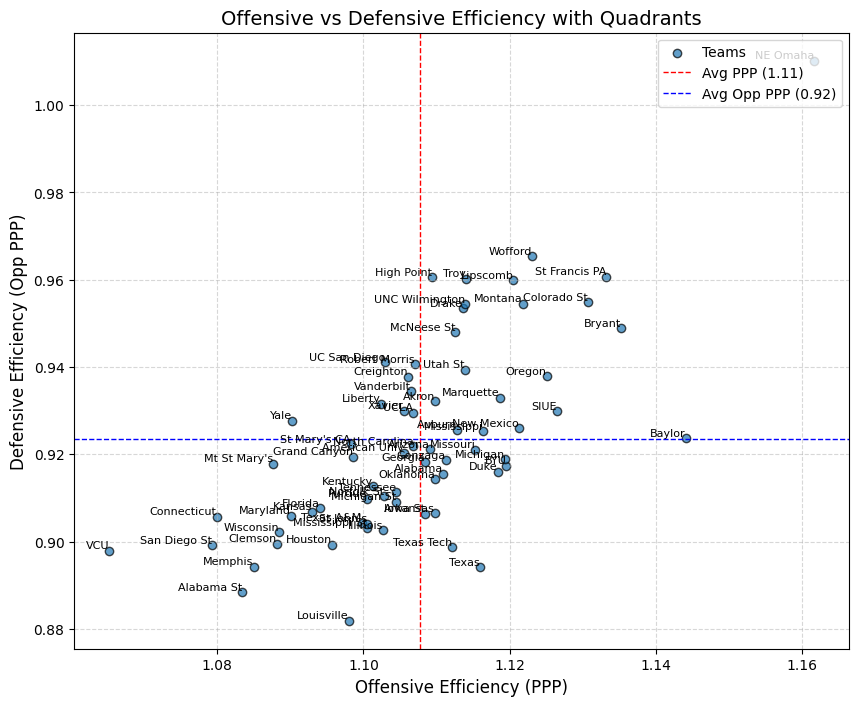

In [47]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
from google.colab import files
filtered_final_rankings = pd.read_csv('Filtered_Final_Team_Rankings.csv')

# Calculate the averages for PPP and Opp PPP
avg_ppp = filtered_final_rankings['PPP'].mean()
avg_opp_ppp = filtered_final_rankings['Opp PPP'].mean()

# Create the scatter plot
plt.figure(figsize=(10, 8))
plt.scatter(
    filtered_final_rankings['PPP'],
    filtered_final_rankings['Opp PPP'],
    alpha=0.7,
    edgecolor='k',
    label='Teams'
)

# Add vertical and horizontal lines for the averages
plt.axvline(avg_ppp, color='red', linestyle='--', linewidth=1, label=f'Avg PPP ({avg_ppp:.2f})')
plt.axhline(avg_opp_ppp, color='blue', linestyle='--', linewidth=1, label=f'Avg Opp PPP ({avg_opp_ppp:.2f})')

# Add team names as labels
for i, row in filtered_final_rankings.iterrows():
    plt.text(
        row['PPP'], row['Opp PPP'],
        row['TeamName'], fontsize=8, ha='right', va='bottom'
    )

# Add labels, title, and legend
plt.title('Offensive vs Defensive Efficiency with Quadrants', fontsize=14)
plt.xlabel('Offensive Efficiency (PPP)', fontsize=12)
plt.ylabel('Defensive Efficiency (Opp PPP)', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)

# Show the plot
plt.show()


In [48]:
# Import necessary libraries
import pandas as pd

# Load the dataset directly from your Colab environment
filtered_final_rankings = pd.read_csv('Filtered_Final_Team_Rankings.csv')

# Calculate Offensive Rating and Defensive Rating
filtered_final_rankings['OffRtg'] = filtered_final_rankings['PPP'] * 100
filtered_final_rankings['DefRtg'] = filtered_final_rankings['Opp PPP'] * 100

# Rank the Offensive and Defensive Ratings
filtered_final_rankings['OffRtg Rank'] = filtered_final_rankings['OffRtg'].rank(ascending=False).astype(int)
filtered_final_rankings['DefRtg Rank'] = filtered_final_rankings['DefRtg'].rank(ascending=True).astype(int)

# Save the updated dataset to a new CSV file
filtered_final_rankings.to_csv('Updated_Team_Rankings_with_Ratings.csv', index=False)

# Download the updated file to your local machine
from google.colab import files
files.download('Updated_Team_Rankings_with_Ratings.csv')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [49]:
# Print the first few rows of the updated dataset
print("Head of Updated Team Rankings with Ratings:")
print(filtered_final_rankings.head())


Head of Updated Team Rankings with Ratings:
   Season Seed  TeamID   TeamName   POM   KPI   SRS   USA   SPR   RPI  ...  \
0    2025  W01    1181       Duke   1.0   7.0   1.0   1.0   5.0   5.0  ...   
1    2025  W02    1104    Alabama   6.0   2.0   5.0   8.0   3.0   2.0  ...   
2    2025  W03    1458  Wisconsin  12.0  22.0  18.0  14.0  21.0  24.0  ...   
3    2025  W04    1112    Arizona  16.0  28.0  11.0  24.0  29.0  37.0  ...   
4    2025  W05    1332     Oregon  31.0  10.0  33.0   NaN  17.0  14.0  ...   

        FTR   Opp PPP  Opp eFG%      DRB%   Opp TO%   Opp FTR      OffRtg  \
0  0.371652  0.916047  0.448306  0.696329  0.177615  0.272343  111.835874   
1  0.412709  0.915571  0.438752  0.682076  0.167720  0.299042  111.092120   
2  0.359528  0.902143  0.449549  0.756068  0.167292  0.255296  108.846181   
3  0.353196  0.921148  0.455353  0.706981  0.171795  0.282770  110.911349   
4  0.398410  0.937963  0.462523  0.715254  0.176330  0.303448  112.510663   

      DefRtg  OffRtg Ran

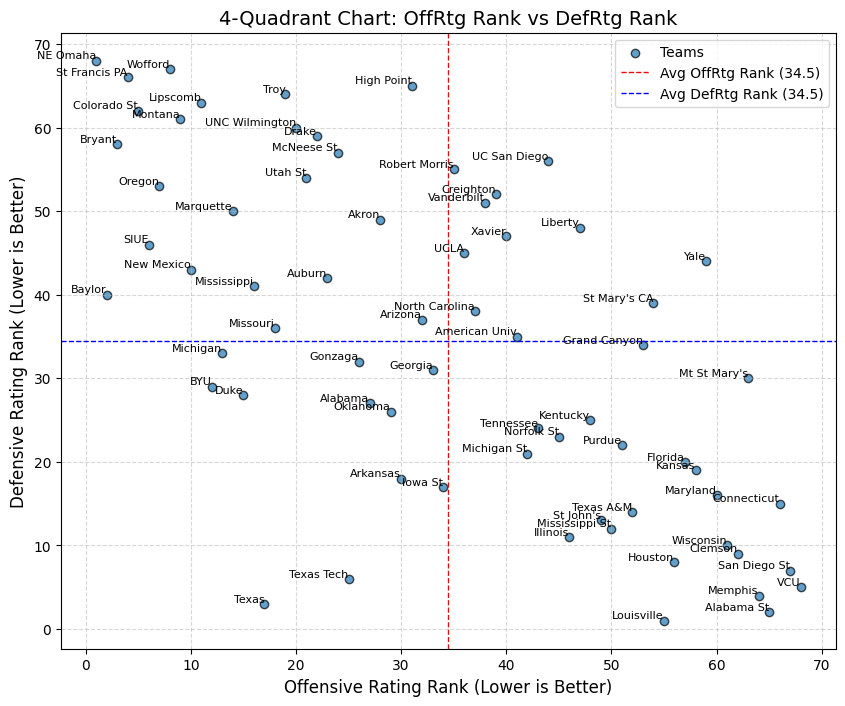

In [50]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset if not already loaded
filtered_final_rankings = pd.read_csv('Updated_Team_Rankings_with_Ratings.csv')

# Calculate the midpoints for the ranks
mid_offrtg = filtered_final_rankings['OffRtg Rank'].mean()
mid_defrtg = filtered_final_rankings['DefRtg Rank'].mean()

# Create the scatter plot
plt.figure(figsize=(10, 8))
plt.scatter(
    filtered_final_rankings['OffRtg Rank'],
    filtered_final_rankings['DefRtg Rank'],
    alpha=0.7,
    edgecolor='k',
    label='Teams'
)

# Add vertical and horizontal lines for the midpoints
plt.axvline(mid_offrtg, color='red', linestyle='--', linewidth=1, label=f'Avg OffRtg Rank ({mid_offrtg:.1f})')
plt.axhline(mid_defrtg, color='blue', linestyle='--', linewidth=1, label=f'Avg DefRtg Rank ({mid_defrtg:.1f})')

# Add team names as labels
for i, row in filtered_final_rankings.iterrows():
    plt.text(
        row['OffRtg Rank'], row['DefRtg Rank'],
        row['TeamName'], fontsize=8, ha='right', va='bottom'
    )

# Add labels, title, and legend
plt.title('4-Quadrant Chart: OffRtg Rank vs DefRtg Rank', fontsize=14)
plt.xlabel('Offensive Rating Rank (Lower is Better)', fontsize=12)
plt.ylabel('Defensive Rating Rank (Lower is Better)', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)

# Show the plot
plt.show()


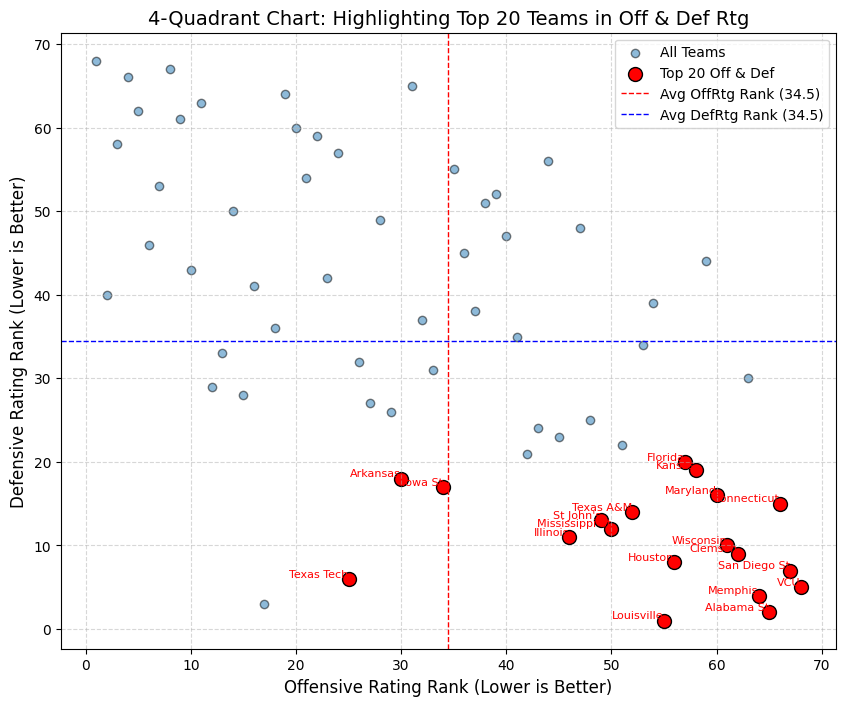

In [51]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset if not already loaded
filtered_final_rankings = pd.read_csv('Updated_Team_Rankings_with_Ratings.csv')

# Calculate the midpoints for the ranks
mid_offrtg = filtered_final_rankings['OffRtg Rank'].mean()
mid_defrtg = filtered_final_rankings['DefRtg Rank'].mean()

# Identify teams in the top 20 for both OffRtg and DefRtg ranks
top_teams = filtered_final_rankings[
    (filtered_final_rankings['OffRtg Rank'] >= 20) &
    (filtered_final_rankings['DefRtg Rank'] <= 20)
]

# Create the scatter plot
plt.figure(figsize=(10, 8))

# Plot all teams
plt.scatter(
    filtered_final_rankings['OffRtg Rank'],
    filtered_final_rankings['DefRtg Rank'],
    alpha=0.5,
    edgecolor='k',
    label='All Teams'
)

# Highlight top 20 teams
plt.scatter(
    top_teams['OffRtg Rank'],
    top_teams['DefRtg Rank'],
    color='red',
    label='Top 20 Off & Def',
    s=100,  # Larger size for emphasis
    edgecolor='black'
)

# Add vertical and horizontal lines for the midpoints
plt.axvline(mid_offrtg, color='red', linestyle='--', linewidth=1, label=f'Avg OffRtg Rank ({mid_offrtg:.1f})')
plt.axhline(mid_defrtg, color='blue', linestyle='--', linewidth=1, label=f'Avg DefRtg Rank ({mid_defrtg:.1f})')

# Add team names as labels for highlighted teams
for i, row in top_teams.iterrows():
    plt.text(
        row['OffRtg Rank'], row['DefRtg Rank'],
        row['TeamName'], fontsize=8, ha='right', va='bottom', color='red'
    )

# Add labels, title, and legend
plt.title('4-Quadrant Chart: Highlighting Top 20 Teams in Off & Def Rtg', fontsize=14)
plt.xlabel('Offensive Rating Rank (Lower is Better)', fontsize=12)
plt.ylabel('Defensive Rating Rank (Lower is Better)', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)

# Show the plot
plt.show()


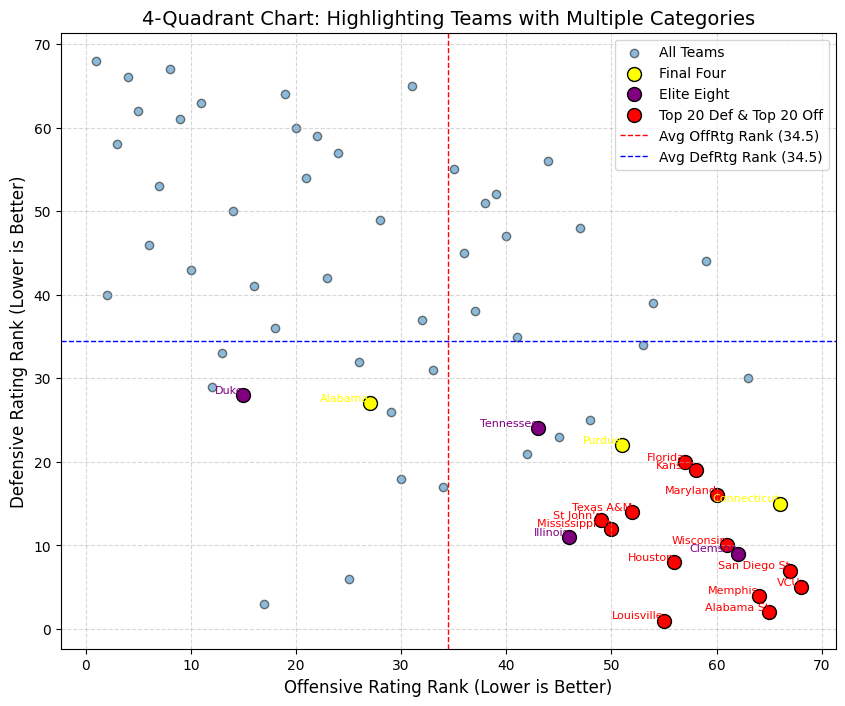

In [52]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset if not already loaded
filtered_final_rankings = pd.read_csv('Updated_Team_Rankings_with_Ratings.csv')

# Calculate the midpoints for the ranks
mid_offrtg = filtered_final_rankings['OffRtg Rank'].mean()
mid_defrtg = filtered_final_rankings['DefRtg Rank'].mean()

# Define specific teams for highlighting
yellow_teams = ['Purdue', 'Connecticut', 'Alabama', 'NC State']
purple_teams = ['Tennessee', 'Duke', 'Illinois', 'Clemson']

# Assign highlight categories
filtered_final_rankings['Highlight'] = 'None'
filtered_final_rankings.loc[filtered_final_rankings['TeamName'].isin(yellow_teams), 'Highlight'] = 'Yellow'
filtered_final_rankings.loc[filtered_final_rankings['TeamName'].isin(purple_teams), 'Highlight'] = 'Purple'
filtered_final_rankings.loc[
    (filtered_final_rankings['Highlight'] == 'None') &
    (filtered_final_rankings['DefRtg Rank'] <= 20) &
    (filtered_final_rankings['OffRtg Rank'] > (filtered_final_rankings['OffRtg Rank'].max() - 20)),
    'Highlight'
] = 'Red'

# Create the scatter plot
plt.figure(figsize=(10, 8))

# Plot all teams
plt.scatter(
    filtered_final_rankings.loc[filtered_final_rankings['Highlight'] == 'None', 'OffRtg Rank'],
    filtered_final_rankings.loc[filtered_final_rankings['Highlight'] == 'None', 'DefRtg Rank'],
    alpha=0.5, edgecolor='k', label='All Teams'
)

# Highlight yellow (Final Four) teams
plt.scatter(
    filtered_final_rankings.loc[filtered_final_rankings['Highlight'] == 'Yellow', 'OffRtg Rank'],
    filtered_final_rankings.loc[filtered_final_rankings['Highlight'] == 'Yellow', 'DefRtg Rank'],
    color='yellow', label='Final Four', s=100, edgecolor='black'
)

# Highlight purple (Elite Eight) teams
plt.scatter(
    filtered_final_rankings.loc[filtered_final_rankings['Highlight'] == 'Purple', 'OffRtg Rank'],
    filtered_final_rankings.loc[filtered_final_rankings['Highlight'] == 'Purple', 'DefRtg Rank'],
    color='purple', label='Elite Eight', s=100, edgecolor='black'
)

# Highlight red (Top 20 Def & Bottom 20 Off)
plt.scatter(
    filtered_final_rankings.loc[filtered_final_rankings['Highlight'] == 'Red', 'OffRtg Rank'],
    filtered_final_rankings.loc[filtered_final_rankings['Highlight'] == 'Red', 'DefRtg Rank'],
    color='red', label='Top 20 Def & Top 20 Off', s=100, edgecolor='black'
)

# Add vertical and horizontal lines for the midpoints
plt.axvline(mid_offrtg, color='red', linestyle='--', linewidth=1, label=f'Avg OffRtg Rank ({mid_offrtg:.1f})')
plt.axhline(mid_defrtg, color='blue', linestyle='--', linewidth=1, label=f'Avg DefRtg Rank ({mid_defrtg:.1f})')

# Add team labels for yellow, purple, and red teams
for i, row in filtered_final_rankings[filtered_final_rankings['Highlight'].isin(['Yellow', 'Purple', 'Red'])].iterrows():
    plt.text(
        row['OffRtg Rank'], row['DefRtg Rank'],
        row['TeamName'], fontsize=8, ha='right', va='bottom',
        color='yellow' if row['Highlight'] == 'Yellow' else (
            'purple' if row['Highlight'] == 'Purple' else 'red'
        )
    )

# Add labels, title, and legend
plt.title('4-Quadrant Chart: Highlighting Teams with Multiple Categories', fontsize=14)
plt.xlabel('Offensive Rating Rank (Lower is Better)', fontsize=12)
plt.ylabel('Defensive Rating Rank (Lower is Better)', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)

# Show the plot
plt.show()


Create a graph that looks at this but for rebounds and shooting percentage, and assist to turnover ration

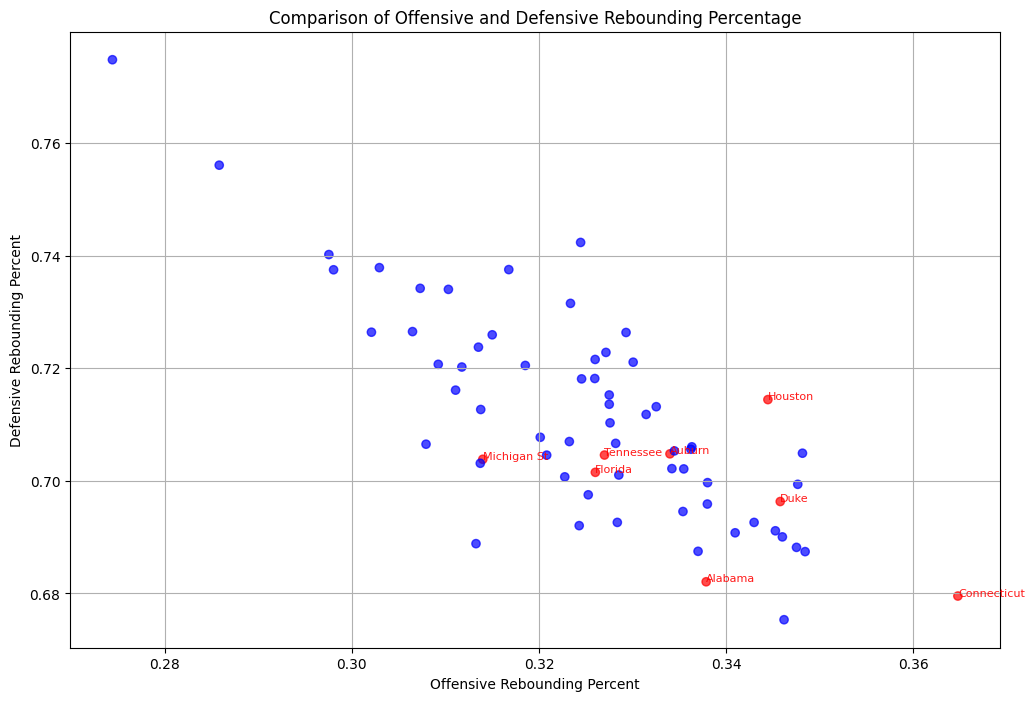

In [53]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
file_path = 'Updated_Team_Rankings_with_Ratings.csv'
data = pd.read_csv(file_path)

# Filter necessary columns
team_names = data['TeamName']
off_efg = data['ORB%']
def_efg = data['DRB%']

# Teams to highlight
highlight_teams = [
    "Connecticut", "Florida", "Auburn", "Alabama",
    "Duke", "Houston", "Michigan St", "Tennessee"
]

# Determine colors
colors = ['red' if team in highlight_teams else 'blue' for team in team_names]

# Plot the data
plt.figure(figsize=(12, 8))
plt.scatter(off_efg, def_efg, c=colors, alpha=0.7)
plt.xlabel('Offensive Rebounding Percent')
plt.ylabel('Defensive Rebounding Percent')
plt.title('Comparison of Offensive and Defensive Rebounding Percentage')
plt.grid(True)

# Add team names as annotations (optional)
for i, team in enumerate(team_names):
    if team in highlight_teams:
        plt.annotate(team, (off_efg[i], def_efg[i]), fontsize=8, alpha=0.9, color='red')

plt.show()


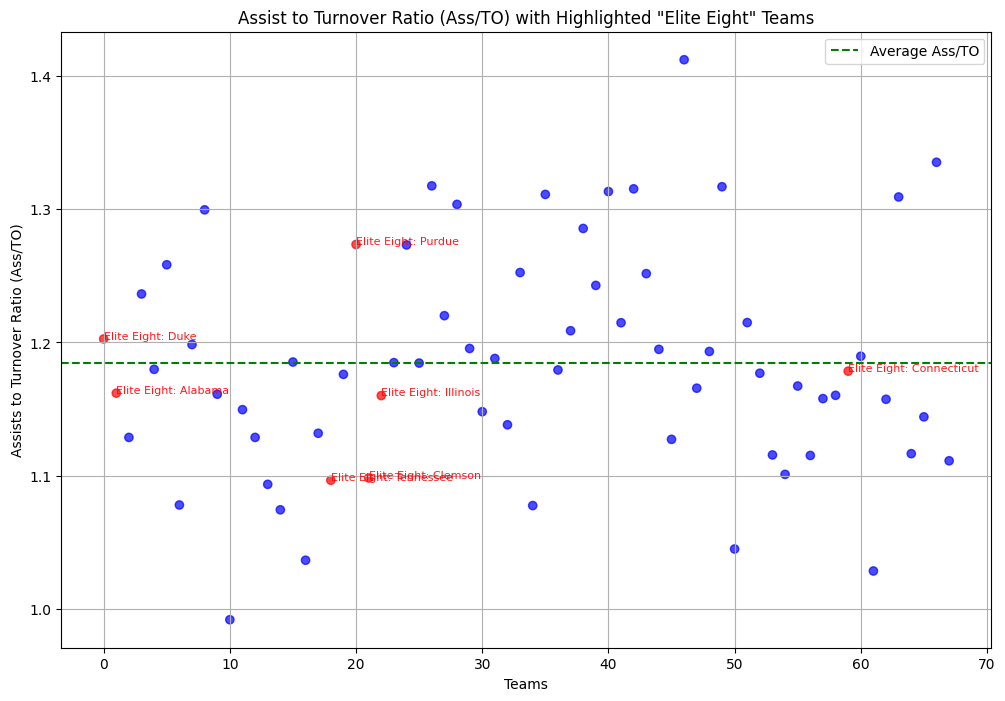

In [54]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
file_path = 'Updated_Team_Rankings_with_Ratings.csv'
data = pd.read_csv(file_path)

# Filter necessary columns
team_names = data['TeamName']
ass_to = data['AST/TO']

# Teams to highlight
elite_eight_teams = [
    "Connecticut", "Illinois", "Clemson", "Alabama",
    "Duke", "NC State", "Purdue", "Tennessee"
]

# Determine colors and labels
colors = ['red' if team in elite_eight_teams else 'blue' for team in team_names]

# Plot the data
plt.figure(figsize=(12, 8))
plt.scatter(range(len(ass_to)), ass_to, c=colors, alpha=0.7)
plt.axhline(y=ass_to.mean(), color='green', linestyle='--', label='Average Ass/TO')
plt.xlabel('Teams')
plt.ylabel('Assists to Turnover Ratio (Ass/TO)')
plt.title('Assist to Turnover Ratio (Ass/TO) with Highlighted "Elite Eight" Teams')
plt.grid(True)

# Add labels for highlighted teams
for i, team in enumerate(team_names):
    if team in elite_eight_teams:
        plt.annotate("Elite Eight: " + team, (i, ass_to.iloc[i]), fontsize=8, color='red', alpha=0.9)

plt.legend()
plt.show()


In [55]:
# Import necessary libraries
import pandas as pd
from google.colab import files

# File paths
file_path_original = 'Updated_Team_Rankings_with_Ratings.csv'
file_path_new = 'Cleaned_Overall_Defensive_Averages.csv'

# Load the datasets
original_data = pd.read_csv(file_path_original)
new_data = pd.read_csv(file_path_new)

# Merge the datasets using TeamID
merged_data = pd.merge(original_data, new_data[['TeamID', 'LScore']], on='TeamID', how='left')

# Rename 'LScore' to 'PPG' for clarity
merged_data.rename(columns={'LScore': 'PPG'}, inplace=True)

# Save the merged data to a file
merged_file_name = 'Updated_Team_Rankings_with_Ratings_MERGED.csv'
merged_data.to_csv(merged_file_name, index=False)

# Display the first few rows of the merged dataset
display(merged_data.head())

# Download the merged CSV so you can view it
files.download(merged_file_name)


,Season,Seed,TeamID,TeamName,POM,KPI,SRS,USA,SPR,RPI,...,Opp PPP,Opp eFG%,DRB%,Opp TO%,Opp FTR,OffRtg,DefRtg,OffRtg Rank,DefRtg Rank,PPG
0,2025,W01,1181,Duke,1.0,7.0,1.0,1.0,5.0,5.0,...,0.916047,0.448306,0.696329,0.177615,0.272343,111.835874,91.604692,15,28,63.696517
1,2025,W02,1104,Alabama,6.0,2.0,5.0,8.0,3.0,2.0,...,0.915571,0.438752,0.682076,0.167720,0.299042,111.092120,91.557073,27,27,64.334086
2,2025,W03,1458,Wisconsin,12.0,22.0,18.0,14.0,21.0,24.0,...,0.902143,0.449549,0.756068,0.167292,0.255296,108.846181,90.214279,61,10,57.582061
3,2025,W04,1112,Arizona,16.0,28.0,11.0,24.0,29.0,37.0,...,0.921148,0.455353,0.706981,0.171795,0.282770,110.911349,92.114760,32,37,65.046041
4,2025,W05,1332,Oregon,31.0,10.0,33.0,NaN,17.0,14.0,...,0.937963,0.462523,0.715254,0.176330,0.303448,112.510663,93.796339,7,53,65.063559


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [56]:
# Import necessary libraries
import pandas as pd
from google.colab import files

# Load your merged dataset
file_path = 'Updated_Team_Rankings_with_Ratings_MERGED.csv'  # adjust if needed
merged_data = pd.read_csv(file_path)

# List of team names to remove
teams_to_remove = ['San Diego St', "St Francis PA", 'Texas', "Mt St Mary's"]

# Remove rows where 'TeamName' is in that list
filtered_data = merged_data[~merged_data['TeamName'].isin(teams_to_remove)].reset_index(drop=True)

# Save the cleaned file
cleaned_file_name = 'Updated_Team_Rankings_with_Ratings_CLEAN.csv'
filtered_data.to_csv(cleaned_file_name, index=False)

# Display rows 15 through 20 to confirm
display(filtered_data.iloc[15:21])

# Download the cleaned file so you can open it
files.download(cleaned_file_name)



,Season,Seed,TeamID,TeamName,POM,KPI,SRS,USA,SPR,RPI,...,Opp PPP,Opp eFG%,DRB%,Opp TO%,Opp FTR,OffRtg,DefRtg,OffRtg Rank,DefRtg Rank,PPG
15,2025,W16a,1110,American Univ,248.0,217.0,261.0,NaN,263.0,157.0,...,0.920396,0.455456,0.725939,0.174910,0.319614,110.548813,92.039621,41,35,59.653179
16,2025,X01,1222,Houston,3.0,5.0,3.0,2.0,7.0,6.0,...,0.899331,0.437757,0.714431,0.185858,0.352718,109.576210,89.933123,56,8,61.084926
17,2025,X02,1397,Tennessee,5.0,4.0,6.0,6.0,4.0,3.0,...,0.911361,0.448377,0.704585,0.184982,0.319807,110.445473,91.136121,43,24,63.014799
18,2025,X03,1246,Kentucky,11.0,8.0,12.0,19.0,6.0,9.0,...,0.912758,0.439709,0.690048,0.168203,0.289003,110.128120,91.275803,48,25,63.064286
19,2025,X04,1345,Purdue,14.0,11.0,15.0,20.0,14.0,12.0,...,0.909852,0.449751,0.718176,0.173366,0.275761,110.044658,90.985235,51,22,61.381148
20,2025,X05,1155,Clemson,19.0,18.0,27.0,10.0,22.0,15.0,...,0.899497,0.447454,0.704567,0.187794,0.281636,108.814861,89.949702,62,9,60.878505


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [57]:
# Import necessary libraries
import pandas as pd
from google.colab import files

# Load the cleaned data
file_path = 'Updated_Team_Rankings_with_Ratings_CLEAN.csv'  # use the cleaned file
data = pd.read_csv(file_path)

# Define the teams and their new seeds
seed_updates = {
    'American Univ': 'W16',
    'Xavier': 'X11',
    'North Carolina': 'Y11',
    'Alabama St': 'Y16'
}

# Update the 'Seed' column for those teams
for team, new_seed in seed_updates.items():
    data.loc[data['TeamName'] == team, 'Seed'] = new_seed

# Save the updated data
updated_file_name = 'Updated_Team_Rankings_with_Ratings.csv'
data.to_csv(updated_file_name, index=False)

# Display a preview of updated teams to confirm changes
display(data[data['TeamName'].isin(seed_updates.keys())][['TeamName', 'Seed']])

# Download the updated file
files.download(updated_file_name)


,TeamName,Seed
15,American Univ,W16
26,Xavier,X11
42,North Carolina,Y11
47,Alabama St,Y16


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

New bracket creation 3/18

In [58]:
# Import necessary libraries
import pandas as pd

# Load the dataset
file_path = 'Updated_Team_Rankings_with_Ratings.csv'  # Ensure the file is uploaded to Colab
data = pd.read_csv(file_path)

# Define the patterns for "Round of 64"
pattern_w = ["R1W1", "R1W2", "R1W3", "R1W4", "R1W5", "R1W6", "R1W7", "R1W8",
             "R1W8", "R1W7", "R1W6", "R1W5", "R1W4", "R1W3", "R1W2", "R1W1"]
pattern_x = [p.replace("W", "X") for p in pattern_w]
pattern_y = [p.replace("W", "Y") for p in pattern_w]
pattern_z = [p.replace("W", "Z") for p in pattern_w]

# Combine all the patterns into a single column "Round of 64"
combined_rounds = pattern_w + pattern_x + pattern_y + pattern_z

# Add the new column to the dataset
data['Round of 64'] = combined_rounds * (len(data) // len(combined_rounds)) + combined_rounds[:len(data) % len(combined_rounds)]

# Save the updated dataset
output_path = 'Updated_Team_Rankings_with_Round_of_64_Combined.csv'
data.to_csv(output_path, index=False)

# Display the updated dataset
print("Updated Dataset:")
print(data.head())

# Provide download link for the updated file
from google.colab import files
files.download(output_path)


Updated Dataset:
   Season Seed  TeamID   TeamName   POM   KPI   SRS   USA   SPR   RPI  ...  \
0    2025  W01    1181       Duke   1.0   7.0   1.0   1.0   5.0   5.0  ...   
1    2025  W02    1104    Alabama   6.0   2.0   5.0   8.0   3.0   2.0  ...   
2    2025  W03    1458  Wisconsin  12.0  22.0  18.0  14.0  21.0  24.0  ...   
3    2025  W04    1112    Arizona  16.0  28.0  11.0  24.0  29.0  37.0  ...   
4    2025  W05    1332     Oregon  31.0  10.0  33.0   NaN  17.0  14.0  ...   

   Opp eFG%      DRB%   Opp TO%   Opp FTR      OffRtg     DefRtg  OffRtg Rank  \
0  0.448306  0.696329  0.177615  0.272343  111.835874  91.604692           15   
1  0.438752  0.682076  0.167720  0.299042  111.092120  91.557073           27   
2  0.449549  0.756068  0.167292  0.255296  108.846181  90.214279           61   
3  0.455353  0.706981  0.171795  0.282770  110.911349  92.114760           32   
4  0.462523  0.715254  0.176330  0.303448  112.510663  93.796339            7   

   DefRtg Rank        PPG  

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [59]:
# Import necessary libraries
import pandas as pd

# Load the dataset
file_path = 'Updated_Team_Rankings_with_Round_of_64_Combined.csv'  # Ensure the file is uploaded to Colab
data = pd.read_csv(file_path)

# Define the patterns for "Round of 32"
pattern_round_32_w = ["R2W1", "R2W2", "R2W3", "R2W4", "R2W4", "R2W3", "R2W2", "R2W1",
                      "R2W1", "R2W2", "R2W3", "R2W4", "R2W4", "R2W3", "R2W2", "R2W1"]
pattern_round_32_x = [p.replace("W", "X") for p in pattern_round_32_w]
pattern_round_32_y = [p.replace("W", "Y") for p in pattern_round_32_w]
pattern_round_32_z = [p.replace("W", "Z") for p in pattern_round_32_w]

# Combine all the patterns into a single column "Round of 32"
combined_round_32 = (pattern_round_32_w + pattern_round_32_x +
                     pattern_round_32_y + pattern_round_32_z)

# Add the new column to the dataset
data['Round of 32'] = (combined_round_32 * (len(data) // len(combined_round_32)) +
                       combined_round_32[:len(data) % len(combined_round_32)])

# Save the updated dataset
output_path = 'Updated_Team_Rankings_with_Rounds_of_64_and_32.csv'
data.to_csv(output_path, index=False)

# Display the updated dataset
print("Updated Dataset with Round of 32:")
print(data.head())

# Provide download link for the updated file
from google.colab import files
files.download(output_path)


Updated Dataset with Round of 32:
   Season Seed  TeamID   TeamName   POM   KPI   SRS   USA   SPR   RPI  ...  \
0    2025  W01    1181       Duke   1.0   7.0   1.0   1.0   5.0   5.0  ...   
1    2025  W02    1104    Alabama   6.0   2.0   5.0   8.0   3.0   2.0  ...   
2    2025  W03    1458  Wisconsin  12.0  22.0  18.0  14.0  21.0  24.0  ...   
3    2025  W04    1112    Arizona  16.0  28.0  11.0  24.0  29.0  37.0  ...   
4    2025  W05    1332     Oregon  31.0  10.0  33.0   NaN  17.0  14.0  ...   

       DRB%   Opp TO%   Opp FTR      OffRtg     DefRtg  OffRtg Rank  \
0  0.696329  0.177615  0.272343  111.835874  91.604692           15   
1  0.682076  0.167720  0.299042  111.092120  91.557073           27   
2  0.756068  0.167292  0.255296  108.846181  90.214279           61   
3  0.706981  0.171795  0.282770  110.911349  92.114760           32   
4  0.715254  0.176330  0.303448  112.510663  93.796339            7   

   DefRtg Rank        PPG  Round of 64  Round of 32  
0           28  

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [60]:
# Import necessary libraries
import pandas as pd

# Load the dataset
file_path = 'Updated_Team_Rankings_with_Rounds_of_64_and_32.csv'  # Ensure the file is uploaded to Colab
data = pd.read_csv(file_path)

# Define the patterns for "Sweet 16"
pattern_sweet_16_w = ["R3W1", "R3W2", "R3W2", "R3W1", "R3W1", "R3W2", "R3W2", "R3W1",
                      "R3W1", "R3W2", "R3W2", "R3W1", "R3W1", "R3W2", "R3W2", "R3W1"]
pattern_sweet_16_x = [p.replace("W", "X") for p in pattern_sweet_16_w]
pattern_sweet_16_y = [p.replace("W", "Y") for p in pattern_sweet_16_w]
pattern_sweet_16_z = [p.replace("W", "Z") for p in pattern_sweet_16_w]

# Combine all the patterns into a single column "Sweet 16"
combined_sweet_16 = (pattern_sweet_16_w + pattern_sweet_16_x +
                     pattern_sweet_16_y + pattern_sweet_16_z)

# Add the new column to the dataset
data['Sweet 16'] = (combined_sweet_16 * (len(data) // len(combined_sweet_16)) +
                    combined_sweet_16[:len(data) % len(combined_sweet_16)])

# Save the updated dataset
output_path = 'Updated_Team_Rankings_with_Sweet_16.csv'
data.to_csv(output_path, index=False)

# Display the updated dataset
print("Updated Dataset with Sweet 16:")
print(data.head())

# Provide download link for the updated file
from google.colab import files
files.download(output_path)


Updated Dataset with Sweet 16:
   Season Seed  TeamID   TeamName   POM   KPI   SRS   USA   SPR   RPI  ...  \
0    2025  W01    1181       Duke   1.0   7.0   1.0   1.0   5.0   5.0  ...   
1    2025  W02    1104    Alabama   6.0   2.0   5.0   8.0   3.0   2.0  ...   
2    2025  W03    1458  Wisconsin  12.0  22.0  18.0  14.0  21.0  24.0  ...   
3    2025  W04    1112    Arizona  16.0  28.0  11.0  24.0  29.0  37.0  ...   
4    2025  W05    1332     Oregon  31.0  10.0  33.0   NaN  17.0  14.0  ...   

    Opp TO%   Opp FTR      OffRtg     DefRtg  OffRtg Rank  DefRtg Rank  \
0  0.177615  0.272343  111.835874  91.604692           15           28   
1  0.167720  0.299042  111.092120  91.557073           27           27   
2  0.167292  0.255296  108.846181  90.214279           61           10   
3  0.171795  0.282770  110.911349  92.114760           32           37   
4  0.176330  0.303448  112.510663  93.796339            7           53   

         PPG  Round of 64  Round of 32  Sweet 16  
0  6

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [61]:
# Import necessary libraries
import pandas as pd

# Load the dataset
file_path = 'Updated_Team_Rankings_with_Sweet_16.csv'  # Ensure the file is uploaded to Colab
data = pd.read_csv(file_path)

# Define the patterns for "Elite Eight"
pattern_elite_eight_w = [
    "R4W1", "R4W1", "R4W1", "R4W1",
    "R4W1", "R4W1", "R4W1", "R4W1",
    "R4W1", "R4W1", "R4W1", "R4W1",
    "R4W1", "R4W1", "R4W1", "R4W1"
]
pattern_elite_eight_x = [p.replace("W", "X") for p in pattern_elite_eight_w]
pattern_elite_eight_y = [p.replace("W", "Y") for p in pattern_elite_eight_w]
pattern_elite_eight_z = [p.replace("W", "Z") for p in pattern_elite_eight_w]

# Combine all the patterns into a single column "Elite Eight"
combined_elite_eight = (pattern_elite_eight_w + pattern_elite_eight_x +
                        pattern_elite_eight_y + pattern_elite_eight_z)

# Add the new column to the dataset
data['Elite Eight'] = (combined_elite_eight * (len(data) // len(combined_elite_eight)) +
                       combined_elite_eight[:len(data) % len(combined_elite_eight)])

# Save the updated dataset
output_path = 'Updated_Team_Rankings_with_Elite_Eight.csv'
data.to_csv(output_path, index=False)

# Display the updated dataset
print("Updated Dataset with Elite Eight:")
print(data.head())

# Provide download link for the updated file
from google.colab import files
files.download(output_path)


Updated Dataset with Elite Eight:
   Season Seed  TeamID   TeamName   POM   KPI   SRS   USA   SPR   RPI  ...  \
0    2025  W01    1181       Duke   1.0   7.0   1.0   1.0   5.0   5.0  ...   
1    2025  W02    1104    Alabama   6.0   2.0   5.0   8.0   3.0   2.0  ...   
2    2025  W03    1458  Wisconsin  12.0  22.0  18.0  14.0  21.0  24.0  ...   
3    2025  W04    1112    Arizona  16.0  28.0  11.0  24.0  29.0  37.0  ...   
4    2025  W05    1332     Oregon  31.0  10.0  33.0   NaN  17.0  14.0  ...   

    Opp FTR      OffRtg     DefRtg  OffRtg Rank  DefRtg Rank        PPG  \
0  0.272343  111.835874  91.604692           15           28  63.696517   
1  0.299042  111.092120  91.557073           27           27  64.334086   
2  0.255296  108.846181  90.214279           61           10  57.582061   
3  0.282770  110.911349  92.114760           32           37  65.046041   
4  0.303448  112.510663  93.796339            7           53  65.063559   

   Round of 64  Round of 32  Sweet 16  Elite E

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [62]:
# Import necessary libraries
import pandas as pd

# Load the dataset
file_path = 'Updated_Team_Rankings_with_Elite_Eight.csv'  # Ensure the file is uploaded to Colab
data = pd.read_csv(file_path)

# Add the "Final Four" column based on conditions in the "Elite Eight" column
data['Final Four'] = data['Elite Eight'].apply(
    lambda x: "R5WX" if x in ["R4W1", "R4X1"] else ("R5YZ" if x in ["R4Y1", "R4Z1"] else None)
)

# Save the updated dataset
output_path = 'Updated_Team_Rankings_with_Final_Four.csv'
data.to_csv(output_path, index=False)

# Display the updated dataset
print("Updated Dataset with Final Four:")
print(data[['Elite Eight', 'Final Four']].head())

# Provide download link for the updated file
from google.colab import files
files.download(output_path)


Updated Dataset with Final Four:
  Elite Eight Final Four
0        R4W1       R5WX
1        R4W1       R5WX
2        R4W1       R5WX
3        R4W1       R5WX
4        R4W1       R5WX


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [63]:
# Import necessary libraries
import pandas as pd

# Load the dataset
file_path = 'Updated_Team_Rankings_with_Final_Four.csv'  # Ensure the file is uploaded to Colab
data = pd.read_csv(file_path)

# Add the "Championship" column based on conditions in the "Final Four" column
data['Championship'] = data['Final Four'].apply(
    lambda x: "R6CH" if x in ["R5WX", "R5YZ"] else None
)

# Save the updated dataset
output_path = 'Updated_Team_Rankings_with_Championship.csv'
data.to_csv(output_path, index=False)

# Display the updated dataset
print("Updated Dataset with Championship:")
print(data[['Final Four', 'Championship']].head())

# Provide download link for the updated file
from google.colab import files
files.download(output_path)


Updated Dataset with Championship:
  Final Four Championship
0       R5WX         R6CH
1       R5WX         R6CH
2       R5WX         R6CH
3       R5WX         R6CH
4       R5WX         R6CH


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Test Run

In [64]:
# Function to simulate each round
def simulate_round(data, round_column, next_round_column, criteria_column):
    winners = []
    for value in data[round_column].unique():
        # Get the teams sharing the same round value
        round_teams = data[data[round_column] == value]

        if len(round_teams) == 2:  # Matchup requires exactly two teams
            # Compare the criteria (e.g., POM score) to determine the winner
            team_1 = round_teams.iloc[0]
            team_2 = round_teams.iloc[1]
            winner = team_1 if team_1[criteria_column] < team_2[criteria_column] else team_2
            winners.append(winner)

    # Convert the list of winners back to a DataFrame
    winners_df = pd.DataFrame(winners)

    # Reset the next round paths for the losers
    data[next_round_column] = data.apply(
        lambda row: row[next_round_column] if row[round_column] in winners_df[round_column].values else None, axis=1
    )
    return winners_df

# Simulate the tournament
rounds = ['Round of 64', 'Round of 32', 'Sweet 16', 'Elite Eight', 'Final Four', 'Championship']
data['Winner Path'] = None  # Initialize a column to track the winning path

for i in range(len(rounds) - 1):
    data = simulate_round(data, rounds[i], rounds[i + 1], criteria_column='POM')

# Save the final results
output_path = 'Tournament_Results.csv'
data.to_csv(output_path, index=False)

# Display the final results
print("Tournament Simulation Results:")
print(data[['TeamID', 'TeamName', 'Winner Path', 'Championship']].head())

# Provide download link for the final results
from google.colab import files
files.download(output_path)


Tournament Simulation Results:
    TeamID TeamName Winner Path Championship
0     1181     Duke        None         R6CH
32    1120   Auburn        None         R6CH


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

It works

Formula rankings
1. KPI, POM,and AVG rank
2. AST/TO and OppTO%
3. PPG
4. eFG% and Opp eFG%
5. PPP, OPPP, OffTtg, DefRTG
6.  ORB%
7. DRB%
8. FTR, OPPFTR
Add a random simulation value where an upset can happen


In [65]:
import pandas as pd
import numpy as np

# Load the dataset
file_path = 'Updated_Team_Rankings_with_Championship.csv'  # Ensure the file is uploaded to Colab
data = pd.read_csv(file_path)

# Define weights for each stat
weights = {
    'KPI': -0.15,
    'POM': -0.15,
    'AverageRank': -0.15,  # Adjust column names as needed
    'AST/TO': 0.15,
    'Opp TO%': -0.15,
    'PPG': 0.1,
    'eFG%': 0.08,
    'Opp eFG%': -0.08,
    'PPP': 0.06,
    'Opp PPP': -0.06,
    'OffRtg': 0.05,
    'DefRtg': 0.05,
    'ORB%': 0.04,
    'DRB%': 0.03,
    'FTR': 0.02,
    'Opp FTR': -0.02
}

# Calculate the weighted score
def calculate_weighted_score(row):
    score = 0
    for stat, weight in weights.items():
        score += weight * row[stat]

    # Add a random upset factor (normalized)
    random_factor = np.random.uniform(0, 0.2)  # Adjust randomness magnitude
    upset_chance = np.random.choice([1, -1], p=[0.85, 0.15])  # 15% chance of upset
    score += random_factor * upset_chance

    return score

# Apply the formula to calculate scores for all teams
data['Weighted_Score'] = data.apply(calculate_weighted_score, axis=1)

# Function to simulate a round using the weighted score
def simulate_round_with_upsets(data, round_column, next_round_column):
    winners = []
    for value in data[round_column].unique():
        # Get the teams sharing the same round value
        round_teams = data[data[round_column] == value]

        if len(round_teams) == 2:  # Matchup requires exactly two teams
            # Compare the weighted scores to determine the winner
            team_1 = round_teams.iloc[0]
            team_2 = round_teams.iloc[1]
            winner = team_1 if team_1['Weighted_Score'] > team_2['Weighted_Score'] else team_2
            winners.append(winner)

    # Convert the list of winners back to a DataFrame
    winners_df = pd.DataFrame(winners)

    # Reset the next round paths for the losers
    data[next_round_column] = data.apply(
        lambda row: row[next_round_column] if row[round_column] in winners_df[round_column].values else None, axis=1
    )
    return winners_df

# Simulate the tournament
rounds = ['Round of 64', 'Round of 32', 'Sweet 16', 'Elite Eight', 'Final Four', 'Championship']

for i in range(len(rounds) - 1):
    data = simulate_round_with_upsets(data, rounds[i], rounds[i + 1])

# Save the final results
output_path = 'Tournament_Results_With_Weighted_Formula_and_Upsets.csv'
data.to_csv(output_path, index=False)

# Display the final results
print("Tournament Simulation Results with Weighted Formula and Upsets:")
print(data[['TeamID', 'TeamName', 'Weighted_Score', 'Championship']].head())

# Provide download link for the final results
from google.colab import files
files.download(output_path)


Tournament Simulation Results with Weighted Formula and Upsets:
    TeamID TeamName  Weighted_Score Championship
0     1181     Duke        15.07739         R6CH
32    1120   Auburn        16.41251         R6CH


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [66]:
# Import necessary libraries
import pandas as pd
import numpy as np

# Upload your dataset to Colab and provide the file path
file_path = 'Updated_Team_Rankings_with_Championship.csv'  # Ensure the file is uploaded to Colab
data = pd.read_csv(file_path)

# Define weights for each stat
weights = {
    'KPI': -0.10,
    'POM': -0.10,
    'AverageRank': -0.10,  # Adjust column names as needed
    'AST/TO': 0.10,
    'Opp TO%': -0.10,
    'PPG': 0.1,
    'eFG%': 0.08,
    'Opp eFG%': -0.08,
    'PPP': 0.06,
    'Opp PPP': -0.06,
    'OffRtg': 0.05,
    'DefRtg': 0.05,
    'ORB%': 0.04,
    'DRB%': 0.03,
    'FTR': 0.02,
    'Opp FTR': -0.02
}

# Function to calculate weighted scores
def calculate_score(row):
    score = 0
    for stat, weight in weights.items():
        if stat in row:
            score += weight * row[stat]
    random_factor = np.random.uniform(0, 0.2)
    upset = np.random.choice([1, -1], p=[0.85, 0.15])  # 15% chance of upset
    score += random_factor * upset
    return score

# Apply the score calculation to the dataset
data['Weighted_Score'] = data.apply(calculate_score, axis=1)

# Function to simulate a single round
def simulate_round(data, current_round_col, next_round_col):
    winners = []
    unique_matchups = data[current_round_col].dropna().unique()

    for matchup in unique_matchups:
        teams = data[data[current_round_col] == matchup]
        if len(teams) == 2:
            team_1 = teams.iloc[0]
            team_2 = teams.iloc[1]
            winner = team_1 if team_1['Weighted_Score'] > team_2['Weighted_Score'] else team_2
            winners.append(winner)

    winners_df = pd.DataFrame(winners)
    if next_round_col:
        data[next_round_col] = data.apply(
            lambda row: row[next_round_col] if row['TeamID'] in winners_df['TeamID'].values else None,
            axis=1,
        )
    return winners_df

# Simulate each round one at a time and save results
rounds = [
    ('Round of 64', 'Round of 32'),
    ('Round of 32', 'Sweet 16'),
    ('Sweet 16', 'Elite Eight'),
    ('Elite Eight', 'Final Four'),
    ('Final Four', 'Championship'),
]

for current_round, next_round in rounds:
    print(f"Simulating {current_round}...")
    results = simulate_round(data, current_round, next_round)
    file_name = f'{current_round.replace(" ", "_")}_Results.csv'
    results.to_csv(file_name, index=False)
    print(f"{current_round} Results:")
    print(results[['TeamID', 'TeamName', 'Weighted_Score']].head())

    # Provide download link
    from google.colab import files
    files.download(file_name)

# Simulate the final round
championship_results = simulate_round(data, 'Championship', None)
championship_results.to_csv('Championship_Results.csv', index=False)
print("Championship Results:")
print(championship_results[['TeamID', 'TeamName', 'Weighted_Score']].head())
files.download('Championship_Results.csv')


Simulating Round of 64...
Round of 64 Results:
   TeamID   TeamName  Weighted_Score
0    1181       Duke       15.563456
1    1104    Alabama       15.631255
2    1458  Wisconsin       10.435293
3    1112    Arizona       10.061532
4    1332     Oregon       10.957714


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Simulating Round of 32...
Round of 32 Results:
    TeamID   TeamName  Weighted_Score
0     1181       Duke       15.563456
1     1104    Alabama       15.631255
2     1458  Wisconsin       10.435293
4     1332     Oregon       10.957714
16    1222    Houston       15.003783


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Championship Results:
    TeamID TeamName  Weighted_Score
32    1120   Auburn       16.231248


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [67]:
def simulate_round_fixed_v2(data, current_round_col, next_round_col):
    winners = []
    unique_matchups = data[current_round_col].dropna().unique()

    for matchup in unique_matchups:
        teams = data[data[current_round_col] == matchup]
        if len(teams) == 2:
            team_1 = teams.iloc[0]
            team_2 = teams.iloc[1]
            winner = team_1 if team_1['Weighted_Score'] > team_2['Weighted_Score'] else team_2
            winners.append(winner)

    winners_df = pd.DataFrame(winners)
    if next_round_col:
        # Update next round column directly in the main dataset based on winners
        data[next_round_col] = data.apply(
            lambda row: row[next_round_col] if row['TeamID'] in winners_df['TeamID'].values else None,
            axis=1,
        )
    return winners_df


In [68]:
# Import necessary libraries
import pandas as pd
import numpy as np

# Upload your dataset to Colab and provide the file path
file_path = 'Updated_Team_Rankings_with_Championship.csv'  # Ensure the file is uploaded to Colab
data = pd.read_csv(file_path)

# Define weights for each stat
weights = {
    'KPI': -0.15,
    'POM': -0.15,
    'AverageRank': -0.15,  # Adjust column names as needed
    'AST/TO': 0.13,
    'Opp TO%': -0.13,
    'PPG': 0.13,
    'eFG%': 0.08,
    'Opp eFG%': -0.08,
    'PPP': 0.06,
    'Opp PPP': -0.06,
    'OffRtg': 0.05,
    'DefRtg': 0.05,
    'ORB%': 0.04,
    'DRB%': 0.03,
    'FTR': 0.02,
    'Opp FTR': -0.02
}

# Function to calculate weighted scores
def calculate_score(row):
    score = 0
    for stat, weight in weights.items():
        if stat in row:
            score += weight * row[stat]
    random_factor = np.random.uniform(0, 0.2)
    upset = np.random.choice([1, -1], p=[0.7, 0.3])  # 30% chance of upset
    score += random_factor * upset
    return score

# Apply the score calculation to the dataset
data['Weighted_Score'] = data.apply(calculate_score, axis=1)

# Function to predict game scores based on weighted scores
def predict_game_scores(team_1_score, team_2_score):
    base_score = 65  # Base score for a team
    variability = np.random.uniform(-5, 5)  # Random variability
    score_1 = base_score + team_1_score + variability
    score_2 = base_score + team_2_score - variability
    return round(score_1), round(score_2)

# Function to simulate a single round
def simulate_round(data, current_round_col, next_round_col):
    winners = []
    game_scores = []
    unique_matchups = data[current_round_col].dropna().unique()

    for matchup in unique_matchups:
        teams = data[data[current_round_col] == matchup]
        if len(teams) == 2:
            team_1 = teams.iloc[0]
            team_2 = teams.iloc[1]
            score_1, score_2 = predict_game_scores(
                team_1['Weighted_Score'], team_2['Weighted_Score']
            )
            game_scores.append((team_1['TeamName'], team_2['TeamName'], score_1, score_2))
            winner = team_1 if score_1 > score_2 else team_2
            winners.append(winner)

    winners_df = pd.DataFrame(winners)
    if next_round_col:
        data[next_round_col] = data.apply(
            lambda row: row[next_round_col] if row['TeamID'] in winners_df['TeamID'].values else None,
            axis=1,
        )

    # Create a DataFrame for game scores
    scores_df = pd.DataFrame(game_scores, columns=['Team1', 'Team2', 'Score1', 'Score2'])
    return winners_df, scores_df

# Simulate each round one at a time and save results
rounds = [
    ('Round of 64', 'Round of 32'),
    ('Round of 32', 'Sweet 16'),
    ('Sweet 16', 'Elite Eight'),
    ('Elite Eight', 'Final Four'),
    ('Final Four', 'Championship'),
]

for current_round, next_round in rounds:
    print(f"Simulating {current_round}...")
    results, scores = simulate_round(data, current_round, next_round)

    # Save the results and scores to CSV
    results_file_name = f'{current_round.replace(" ", "_")}_Results.csv'
    scores_file_name = f'{current_round.replace(" ", "_")}_Scores.csv'
    results.to_csv(results_file_name, index=False)
    scores.to_csv(scores_file_name, index=False)

    print(f"{current_round} Results:")
    print(results[['TeamID', 'TeamName', 'Weighted_Score']].head())
    print(f"{current_round} Scores:")
    print(scores.head())

    # Provide download links for results and scores
    from google.colab import files
    files.download(results_file_name)
    files.download(scores_file_name)

# Simulate the final round
championship_results, championship_scores = simulate_round(data, 'Championship', None)
championship_results.to_csv('Championship_Results.csv', index=False)
championship_scores.to_csv('Championship_Scores.csv', index=False)

print("Championship Results:")
print(championship_results[['TeamID', 'TeamName', 'Weighted_Score']].head())
print("Championship Scores:")
print(championship_scores.head())

# Download championship results and scores
files.download('Championship_Results.csv')
files.download('Championship_Scores.csv')


Simulating Round of 64...
Round of 64 Results:
   TeamID   TeamName  Weighted_Score
0    1181       Duke       17.050367
1    1104    Alabama       16.824857
2    1458  Wisconsin        9.866649
3    1112    Arizona        8.484149
4    1332     Oregon        9.967440
Round of 64 Scores:
       Team1          Team2  Score1  Score2
0       Duke  American Univ      79     -18
1    Alabama  Robert Morris      85      20
2  Wisconsin        Montana      72      19
3    Arizona          Akron      73      46
4     Oregon        Liberty      77      54


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

Championship Results:
    TeamID TeamName  Weighted_Score
32    1120   Auburn       18.343286
Championship Scores:
       Team1   Team2  Score1  Score2
0  Tennessee  Auburn      82      82


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [69]:
# Import necessary libraries
import pandas as pd
import numpy as np

# File path (replace with your actual file path if needed)
file_path = 'Updated_Team_Rankings_with_Championship.csv'
data = pd.read_csv(file_path)

# Define weights for each stat
weights = {
    'KPI': -0.10,
    'POM': -0.10,
    'AverageRank': -0.10,
    'AST/TO': 0.10,
    'Opp TO%': -0.10,
    'PPG': 0.1,
    'eFG%': 0.08,
    'Opp eFG%': -0.08,
    'PPP': 0.06,
    'Opp PPP': -0.06,
    'OffRtg': 0.05,
    'DefRtg': 0.05,
    'ORB%': 0.04,
    'DRB%': 0.03,
    'FTR': 0.02,
    'Opp FTR': -0.02
}

# Updated calculate_score function
def calculate_score(row):
    score = 0
    for stat, weight in weights.items():
        if stat in row:
            score += weight * row[stat]
    return score

# Apply the score calculation to the dataset
data['Weighted_Score'] = data.apply(calculate_score, axis=1)

# Function to predict game scores based on weighted scores
def predict_game_scores(team_1_score, team_2_score):
    base_score = 65  # Base score for a team
    variability = np.random.uniform(-5, 5)  # Random variability
    score_1 = base_score + team_1_score + variability
    score_2 = base_score + team_2_score - variability
    return round(score_1), round(score_2)

# Updated simulate_round function with competitive upset logic
def simulate_round(data, current_round_col, next_round_col):
    winners = []
    game_scores = []
    unique_matchups = data[current_round_col].dropna().unique()

    for matchup in unique_matchups:
        teams = data[data[current_round_col] == matchup]
        if len(teams) == 2:
            team_1 = teams.iloc[0]
            team_2 = teams.iloc[1]

            # Calculate the score difference as a percentage
            score_diff = abs(team_1['Weighted_Score'] - team_2['Weighted_Score'])
            relative_diff = score_diff / max(team_1['Weighted_Score'], team_2['Weighted_Score'])

            # Adjust upset probability for close games (less than 5% score difference)
            if relative_diff < 0.05:
                upset_prob = 0.5  # 50% upset chance for very close games
            else:
                upset_prob = 0.7  # Default 30% upset chance

            # Predict game scores with adjusted upset logic
            upset = np.random.choice([1, -1], p=[upset_prob, 1 - upset_prob])
            score_1, score_2 = predict_game_scores(
                team_1['Weighted_Score'] + (0.1 * upset),
                team_2['Weighted_Score'] - (0.1 * upset)
            )
            game_scores.append((team_1['TeamName'], team_2['TeamName'], score_1, score_2))
            winner = team_1 if score_1 > score_2 else team_2
            winners.append(winner)

    winners_df = pd.DataFrame(winners)
    if next_round_col:
        data[next_round_col] = data.apply(
            lambda row: row[next_round_col] if row['TeamID'] in winners_df['TeamID'].values else None,
            axis=1,
        )

    # Create a DataFrame for game scores
    scores_df = pd.DataFrame(game_scores, columns=['Team1', 'Team2', 'Score1', 'Score2'])
    return winners_df, scores_df

# Simulate each round one at a time and save results
rounds = [
    ('Round of 64', 'Round of 32'),
    ('Round of 32', 'Sweet 16'),
    ('Sweet 16', 'Elite Eight'),
    ('Elite Eight', 'Final Four'),
    ('Final Four', 'Championship'),
]

for current_round, next_round in rounds:
    print(f"Simulating {current_round}...")
    results, scores = simulate_round(data, current_round, next_round)

    # Save the results and scores to CSV
    results_file_name = f'{current_round.replace(" ", "_")}_Results.csv'
    scores_file_name = f'{current_round.replace(" ", "_")}_Scores.csv'
    results.to_csv(results_file_name, index=False)
    scores.to_csv(scores_file_name, index=False)

    print(f"{current_round} Results:")
    print(results[['TeamID', 'TeamName', 'Weighted_Score']].head())
    print(f"{current_round} Scores:")
    print(scores.head())

    # Provide download links for results and scores
    from google.colab import files
    files.download(results_file_name)
    files.download(scores_file_name)

# Simulate the final round
championship_results, championship_scores = simulate_round(data, 'Championship', None)
championship_results.to_csv('Championship_Results.csv', index=False)
championship_scores.to_csv('Championship_Scores.csv', index=False)

print("Championship Results:")
print(championship_results[['TeamID', 'TeamName', 'Weighted_Score']].head())
print("Championship Scores:")
print(championship_scores.head())

# Download championship results and scores
files.download('Championship_Results.csv')
files.download('Championship_Scores.csv')


Simulating Round of 64...
Round of 64 Results:
   TeamID   TeamName  Weighted_Score
0    1181       Duke       15.542771
1    1104    Alabama       15.505562
2    1458  Wisconsin       10.603975
3    1112    Arizona        9.873062
4    1332     Oregon       10.926521
Round of 64 Scores:
       Team1          Team2  Score1  Score2
0       Duke  American Univ      85       8
1    Alabama  Robert Morris      76      46
2  Wisconsin        Montana      72      41
3    Arizona          Akron      73      58
4     Oregon        Liberty      81      58


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

Championship Results:
    TeamID   TeamName  Weighted_Score
49    1385  St John's       12.428528
Championship Scores:
    Team1      Team2  Score1  Score2
0  Purdue  St John's      76      79


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [70]:
import pandas as pd
from google.colab import files

# List of CSVs in order from Round of 64 to Championship
files_in_order = [
    'Round_of_64_Results.csv',
    'Round_of_32_Results.csv',
    'Sweet_16_Results.csv',
    'Elite_Eight_Results.csv',
    'Final_Four_Results.csv',
    'Championship_Results.csv'  # if you have this file, include it!
]

# Initialize an empty dataframe
combined_results = pd.DataFrame()

# Loop through each file, read, and append to combined dataframe
for file_name in files_in_order:
    try:
        df = pd.read_csv(file_name)
        combined_results = pd.concat([combined_results, df], ignore_index=True)
        print(f"✅ Merged {file_name}")
    except FileNotFoundError:
        print(f"⚠️ File not found: {file_name} — skipping.")

# Save combined results to a single CSV
final_merged_file = 'Complete_Tournament_Results_Merged.csv'
combined_results.to_csv(final_merged_file, index=False)

# Download the combined file
files.download(final_merged_file)

# Display first few rows to confirm
combined_results.head()


✅ Merged Round_of_64_Results.csv
✅ Merged Round_of_32_Results.csv
✅ Merged Sweet_16_Results.csv
✅ Merged Elite_Eight_Results.csv
✅ Merged Final_Four_Results.csv
✅ Merged Championship_Results.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

,Season,Seed,TeamID,TeamName,POM,KPI,SRS,USA,SPR,RPI,...,OffRtg Rank,DefRtg Rank,PPG,Round of 64,Round of 32,Sweet 16,Elite Eight,Final Four,Championship,Weighted_Score
0,2025,W01,1181,Duke,1.0,7.0,1.0,1.0,5.0,5.0,...,15,28,63.696517,R1W1,R2W1,R3W1,R4W1,R5WX,R6CH,15.542771
1,2025,W02,1104,Alabama,6.0,2.0,5.0,8.0,3.0,2.0,...,27,27,64.334086,R1W2,R2W2,R3W2,R4W1,R5WX,R6CH,15.505562
2,2025,W03,1458,Wisconsin,12.0,22.0,18.0,14.0,21.0,24.0,...,61,10,57.582061,R1W3,R2W3,R3W2,R4W1,R5WX,R6CH,10.603975
3,2025,W04,1112,Arizona,16.0,28.0,11.0,24.0,29.0,37.0,...,32,37,65.046041,R1W4,R2W4,R3W1,R4W1,R5WX,R6CH,9.873062
4,2025,W05,1332,Oregon,31.0,10.0,33.0,NaN,17.0,14.0,...,7,53,65.063559,R1W5,R2W4,R3W1,R4W1,R5WX,R6CH,10.926521


In [71]:
# Import necessary libraries
import pandas as pd
import numpy as np
from google.colab import files

# File path (replace with your actual file path if needed)
file_path = 'Updated_Team_Rankings_with_Championship.csv'
data = pd.read_csv(file_path)

# Define weights for each stat
weights = {
    'KPI': -0.10, 'POM': -0.10, 'AverageRank': -0.10, 'AST/TO': 0.10, 'Opp TO%': -0.10,
    'PPG': 0.1, 'eFG%': 0.08, 'Opp eFG%': -0.08, 'PPP': 0.06, 'Opp PPP': -0.06,
    'OffRtg': 0.05, 'DefRtg': 0.05, 'ORB%': 0.04, 'DRB%': 0.03, 'FTR': 0.02, 'Opp FTR': -0.02
}

# Calculate weighted scores
def calculate_score(row):
    score = 0
    for stat, weight in weights.items():
        if stat in row:
            score += weight * row[stat]
    return score

data['Weighted_Score'] = data.apply(calculate_score, axis=1)

# Function to predict game scores
def predict_game_scores(team_1_score, team_2_score):
    base_score = 65
    variability = np.random.uniform(-5, 5)
    score_1 = base_score + team_1_score + variability
    score_2 = base_score + team_2_score - variability
    return round(score_1), round(score_2)

# Simulate rounds and store all results in one list
def simulate_round(data, current_round_col, next_round_col, round_name):
    results_list = []
    unique_matchups = data[current_round_col].dropna().unique()

    for matchup in unique_matchups:
        teams = data[data[current_round_col] == matchup]
        if len(teams) == 2:
            team_1 = teams.iloc[0]
            team_2 = teams.iloc[1]

            score_diff = abs(team_1['Weighted_Score'] - team_2['Weighted_Score'])
            relative_diff = score_diff / max(team_1['Weighted_Score'], team_2['Weighted_Score'])
            upset_prob = 0.5 if relative_diff < 0.05 else 0.7

            upset = np.random.choice([1, -1], p=[upset_prob, 1 - upset_prob])
            score_1, score_2 = predict_game_scores(
                team_1['Weighted_Score'] + (0.1 * upset),
                team_2['Weighted_Score'] - (0.1 * upset)
            )
            winner = team_1 if score_1 > score_2 else team_2

            results_list.append({
                'Round': round_name,
                'Team1': team_1['TeamName'],
                'Team2': team_2['TeamName'],
                'Score1': score_1,
                'Score2': score_2,
                'Winner': winner['TeamName']
            })

    return pd.DataFrame(results_list)

# Simulate all rounds and collect results
rounds = [
    ('Round of 64', 'Round of 32'),
    ('Round of 32', 'Sweet 16'),
    ('Sweet 16', 'Elite Eight'),
    ('Elite Eight', 'Final Four'),
    ('Final Four', 'Championship'),
    ('Championship', None)
]

all_games = pd.DataFrame()

for current_round, next_round in rounds:
    round_results = simulate_round(data, current_round, next_round, current_round)
    all_games = pd.concat([all_games, round_results], ignore_index=True)

# Save everything to one spreadsheet
final_file_name = 'Complete_Tournament_Results.csv'
all_games.to_csv(final_file_name, index=False)

# Download the final single spreadsheet
files.download(final_file_name)

# Display first few rows of the full results
all_games.head()


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

,Round,Team1,Team2,Score1,Score2,Winner
0,Round of 64,Duke,American Univ,82,10,Duke
1,Round of 64,Alabama,Robert Morris,83,39,Alabama
2,Round of 64,Wisconsin,Montana,78,35,Wisconsin
3,Round of 64,Arizona,Akron,73,58,Arizona
4,Round of 64,Oregon,Liberty,77,63,Oregon


In [72]:
# Import necessary libraries
import pandas as pd
import numpy as np
from google.colab import files

# Load data
file_path = 'Updated_Team_Rankings_with_Championship.csv'
data = pd.read_csv(file_path)

# Define weights
weights = {
    'KPI': -0.10, 'POM': -0.10, 'AverageRank': -0.10, 'AST/TO': 0.10, 'Opp TO%': -0.10,
    'PPG': 0.1, 'eFG%': 0.08, 'Opp eFG%': -0.08, 'PPP': 0.06, 'Opp PPP': -0.06,
    'OffRtg': 0.05, 'DefRtg': 0.05, 'ORB%': 0.04, 'DRB%': 0.03, 'FTR': 0.02, 'Opp FTR': -0.02
}

# Calculate weighted scores
def calculate_score(row):
    return sum(weight * row[stat] for stat, weight in weights.items() if stat in row)

data['Weighted_Score'] = data.apply(calculate_score, axis=1)

# Function to predict realistic game scores
def predict_game_scores(team_1_score, team_2_score):
    base_score = 65
    variability = np.random.uniform(-5, 5)
    score_1 = base_score + team_1_score + variability
    score_2 = base_score + team_2_score - variability
    return round(score_1), round(score_2)

# Simulate round function with progressive winner tracking
def simulate_round(data, current_round_col, next_round_col, round_name):
    round_results = []
    unique_matchups = data[current_round_col].dropna().unique()

    for matchup in unique_matchups:
        teams = data[data[current_round_col] == matchup]
        if len(teams) == 2:
            team_1 = teams.iloc[0]
            team_2 = teams.iloc[1]

            score_diff = abs(team_1['Weighted_Score'] - team_2['Weighted_Score'])
            relative_diff = score_diff / max(team_1['Weighted_Score'], team_2['Weighted_Score'])
            upset_prob = 0.5 if relative_diff < 0.05 else 0.7

            upset = np.random.choice([1, -1], p=[upset_prob, 1 - upset_prob])
            score_1, score_2 = predict_game_scores(
                team_1['Weighted_Score'] + (0.1 * upset),
                team_2['Weighted_Score'] - (0.1 * upset)
            )
            winner = team_1 if score_1 > score_2 else team_2

            round_results.append({
                'Round': round_name,
                'Matchup': matchup,
                'Team1': team_1['TeamName'],
                'Team2': team_2['TeamName'],
                'Score1': score_1,
                'Score2': score_2,
                'Winner': winner['TeamName']
            })

            # Update winner’s next round matchup
            if next_round_col:
                next_matchup_key = f"{matchup}_{round_name[-2:]}"  # create a unique key for next round
                data.loc[data['TeamID'] == winner['TeamID'], next_round_col] = next_matchup_key

    return pd.DataFrame(round_results), data

# Rounds setup
rounds = [
    ('Round of 64', 'Round of 32'),
    ('Round of 32', 'Sweet 16'),
    ('Sweet 16', 'Elite Eight'),
    ('Elite Eight', 'Final Four'),
    ('Final Four', 'Championship'),
    ('Championship', None)
]

# Initialize empty DataFrame to append all results
all_rounds_results = pd.DataFrame()

# Run simulation for each round, add results to master DataFrame
for current_round, next_round in rounds:
    results_df, data = simulate_round(data, current_round, next_round, current_round)
    all_rounds_results = pd.concat([all_rounds_results, results_df], ignore_index=True)

# Save the full tournament results as one combined CSV
final_filename = 'Complete_Tournament_Results_All_Rounds.csv'
all_rounds_results.to_csv(final_filename, index=False)

# Download the completed results file
files.download(final_filename)

# Display first few rows for confirmation
all_rounds_results.head()


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

,Round,Matchup,Team1,Team2,Score1,Score2,Winner
0,Round of 64,R1W1,Duke,American Univ,83,10,Duke
1,Round of 64,R1W2,Alabama,Robert Morris,80,42,Alabama
2,Round of 64,R1W3,Wisconsin,Montana,74,39,Wisconsin
3,Round of 64,R1W4,Arizona,Akron,76,55,Arizona
4,Round of 64,R1W5,Oregon,Liberty,74,65,Oregon


In [73]:
# Import necessary libraries
import pandas as pd
import numpy as np
from google.colab import files

# Load data
file_path = 'Updated_Team_Rankings_with_Championship.csv'
data = pd.read_csv(file_path)

# Define weights for each stat
weights = {
    'KPI': -0.10, 'POM': -0.10, 'AverageRank': -0.10, 'AST/TO': 0.10, 'Opp TO%': -0.10,
    'PPG': 0.1, 'eFG%': 0.08, 'Opp eFG%': -0.08, 'PPP': 0.06, 'Opp PPP': -0.06,
    'OffRtg': 0.05, 'DefRtg': 0.05, 'ORB%': 0.04, 'DRB%': 0.03, 'FTR': 0.02, 'Opp FTR': -0.02
}

# Calculate weighted scores
def calculate_score(row):
    score = 0
    for stat, weight in weights.items():
        if stat in row:
            score += weight * row[stat]
    return score

data['Weighted_Score'] = data.apply(calculate_score, axis=1)

# Function to predict game scores
def predict_game_scores(team_1_score, team_2_score):
    base_score = 65
    variability = np.random.uniform(-5, 5)
    score_1 = base_score + team_1_score + variability
    score_2 = base_score + team_2_score - variability
    return round(score_1), round(score_2)

# Function to simulate each round and return round results
def simulate_round(current_teams, round_name):
    results_list = []

    for i in range(0, len(current_teams), 2):
        team_1 = current_teams.iloc[i]
        team_2 = current_teams.iloc[i + 1]

        score_diff = abs(team_1['Weighted_Score'] - team_2['Weighted_Score'])
        relative_diff = score_diff / max(team_1['Weighted_Score'], team_2['Weighted_Score'])
        upset_prob = 0.5 if relative_diff < 0.05 else 0.7

        upset = np.random.choice([1, -1], p=[upset_prob, 1 - upset_prob])
        score_1, score_2 = predict_game_scores(
            team_1['Weighted_Score'] + (0.1 * upset),
            team_2['Weighted_Score'] - (0.1 * upset)
        )
        winner = team_1 if score_1 > score_2 else team_2

        results_list.append({
            'Round': round_name,
            'Team1': team_1['TeamName'],
            'Team2': team_2['TeamName'],
            'Score1': score_1,
            'Score2': score_2,
            'Winner': winner['TeamName']
        })

    results_df = pd.DataFrame(results_list)
    winners = data[data['TeamName'].isin(results_df['Winner'])]
    winners = winners.reset_index(drop=True)
    return results_df, winners

# Start simulation from the teams in Round of 64
current_teams = data[data['Round of 64'].notna()].reset_index(drop=True)

all_results = pd.DataFrame()
round_names = ['Round of 64', 'Round of 32', 'Sweet 16', 'Elite Eight', 'Final Four', 'Championship']

# Simulate all rounds and add results to one dataframe
for round_name in round_names:
    round_results, current_teams = simulate_round(current_teams, round_name)
    all_results = pd.concat([all_results, round_results], ignore_index=True)

# Save all results to a single CSV
final_file_name = 'Complete_Tournament_All_Rounds_One_Sheet.csv'
all_results.to_csv(final_file_name, index=False)

# Download the file
files.download(final_file_name)

# Display first few rows
all_results.head()


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

,Round,Team1,Team2,Score1,Score2,Winner
0,Round of 64,Duke,Alabama,77,84,Alabama
1,Round of 64,Wisconsin,Arizona,77,74,Wisconsin
2,Round of 64,Oregon,BYU,80,70,Oregon
3,Round of 64,St Mary's CA,Mississippi St,77,72,St Mary's CA
4,Round of 64,Baylor,Vanderbilt,65,74,Vanderbilt


Creating a graphic

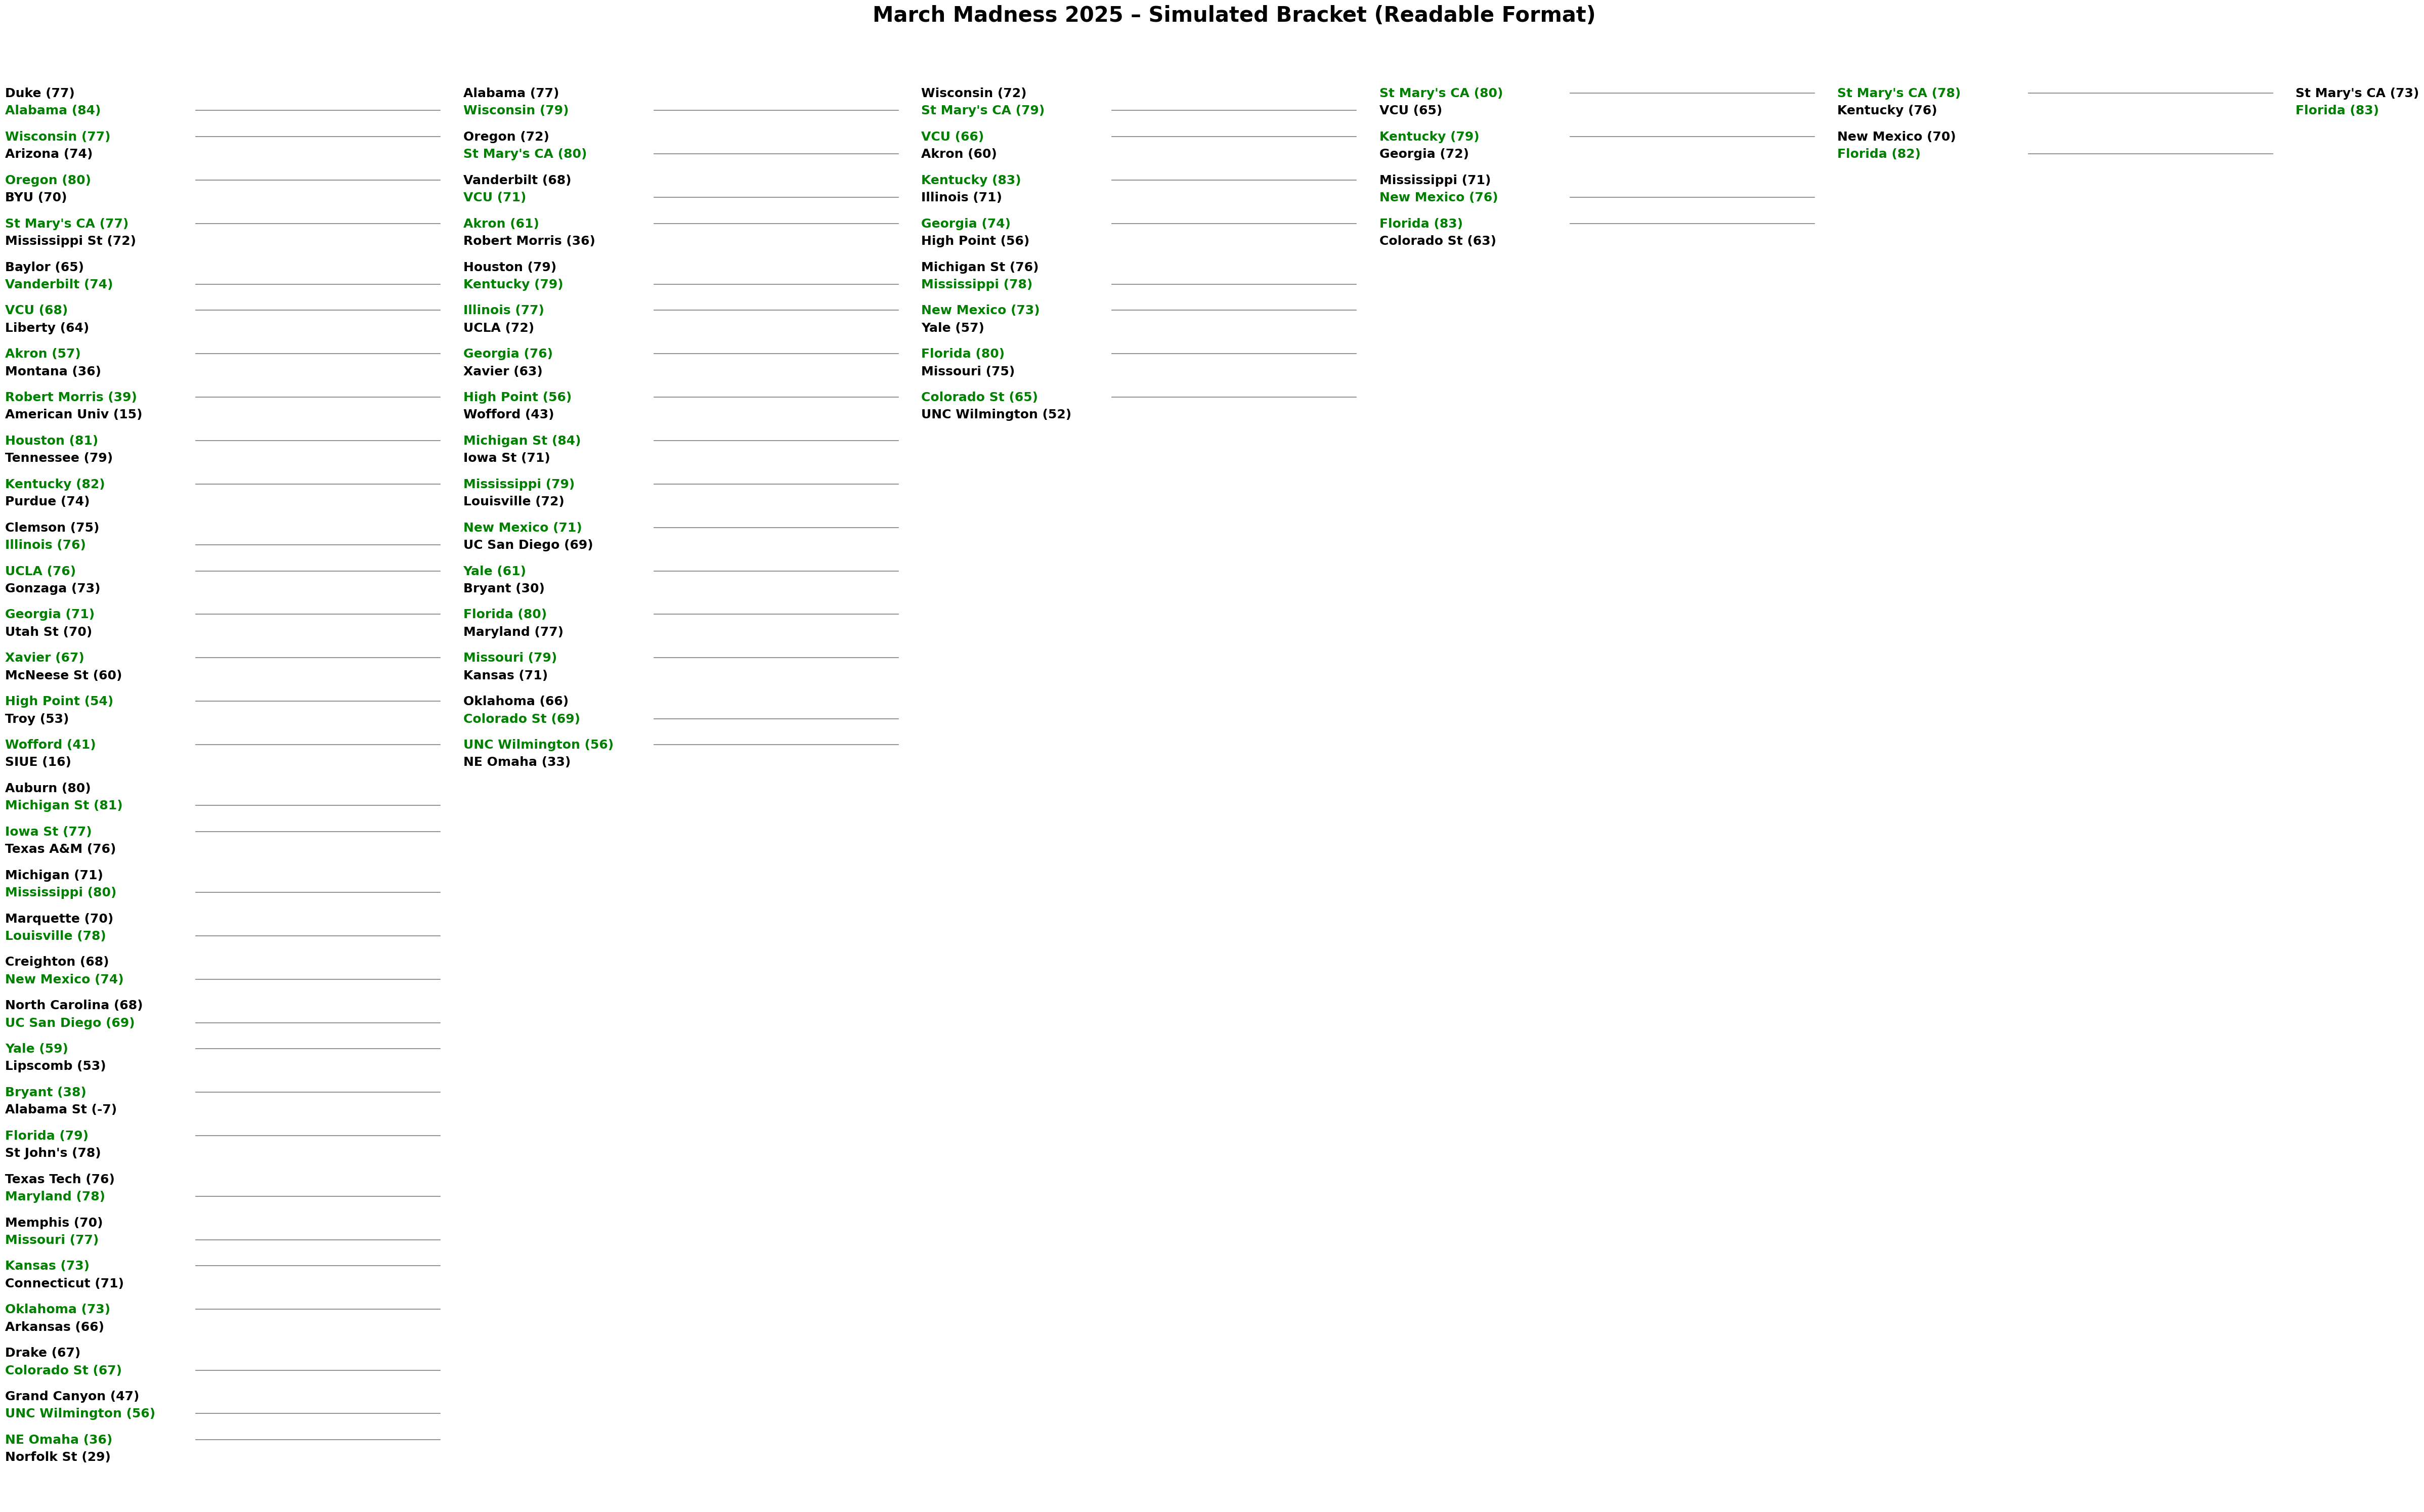

In [74]:
import pandas as pd
import matplotlib.pyplot as plt

# Load CSV
df = pd.read_csv("Complete_Tournament_All_Rounds_One_Sheet.csv")

# Define rounds
rounds = ['Round of 64', 'Round of 32', 'Sweet 16', 'Elite Eight', 'Final Four', 'Championship']
round_data = {r: df[df['Round'] == r].reset_index(drop=True) for r in rounds}

# BIG canvas
fig, ax = plt.subplots(figsize=(48, 30))
ax.axis('off')

# Spacing settings
x_spacing = 6.0
x_positions = {r: i * x_spacing for i, r in enumerate(rounds)}
y_start = 400
matchup_spacing = 20
team_spacing = 8

# Track Y for winners
team_y_positions = {}

# Plot each round
for round_name in rounds:
    matches = round_data[round_name]
    x = x_positions[round_name]

    for i, row in matches.iterrows():
        team1 = row['Team1']
        team2 = row['Team2']
        score1 = row['Score1']
        score2 = row['Score2']
        winner = row['Winner']

        y = y_start - i * matchup_spacing

        # Big, bold text
        ax.text(x, y, f"{team1} ({score1})", ha='left', va='center',
                fontsize=18, fontweight='bold', color='green' if team1 == winner else 'black')
        ax.text(x, y - team_spacing, f"{team2} ({score2})", ha='left', va='center',
                fontsize=18, fontweight='bold', color='green' if team2 == winner else 'black')

        # Track Y for line drawing
        team_y_positions[winner] = y if winner == team1 else y - team_spacing

        # Draw line to next round
        if round_name != 'Championship':
            next_round = rounds[rounds.index(round_name) + 1]
            if winner in round_data[next_round]['Team1'].values or winner in round_data[next_round]['Team2'].values:
                x_next = x_positions[next_round]
                ax.plot([x + 2.5, x_next - 0.3], [team_y_positions[winner]]*2,
                        linestyle='-', color='gray', linewidth=1.2)

# Add title
plt.title("March Madness 2025 – Simulated Bracket (Readable Format)", fontsize=30, fontweight='bold')
plt.tight_layout()
plt.savefig("march_madness_bracket_readable.png", dpi=300)
plt.show()
